<div align="center">

# 🌡️ Smart Room Temperature Control
## *Optimasi Kendali AC Menggunakan Logika Fuzzy, GA, dan ANFIS*

---

**UJIAN TENGAH SEMESTER GENAP 2025/2026**  
Mata Kuliah: **Soft Computing** | Dosen: **Dr. Ir. Intan Nurma Yulita, M.T**

---

| Komponen | Keterangan |
|:---|:---|
| **Studi Kasus** | Smart Room Temperature Control (Kendali Kecepatan Kompresor AC) |
| **Input** | ΔT = Temp_Ruangan − Target (°C), Kelembaban (%), Okupansi (0/1) |
| **Output** | Kecepatan Kompresor (0–100%), Konsumsi Energi (kWh) |
| **Tahap 1** | Manual Sugeno FIS (Human Expert Intuition) |
| **Tahap 2** | Genetic Algorithm (GA) – Evolutionary Tuning of MF parameters |
| **Tahap 3** | ANFIS (Adaptive Neuro-Fuzzy) – ANN-driven MF + Consequent tuning |

> **Alur Kerja:** Human Expert → GA Tuning → ANFIS Tuning  
> Setiap tahap dibandingkan menggunakan MSE, RMSE, MAE, R², dan Efisiensi Energi (kWh)

</div>

---
## SECTION 0: INSTALASI & IMPORT LIBRARY
### 0.1 – Install dependencies

In [1]:
!pip install scikit-fuzzy matplotlib numpy pandas scikit-learn tensorflow deap -q
print('✅ Instalasi selesai!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 18.2 MB/s eta 0:00:00
✅ Instalasi selesai!


### 0.2 – Import semua library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from deap import base, creator, tools, algorithms
import json, pickle, os, warnings, random, copy, time

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

os.makedirs('artifacts/ann_model', exist_ok=True)
os.makedirs('artifacts/ablation', exist_ok=True)

print("✅ Semua library berhasil diimport!")
print(f"   TensorFlow : {tf.__version__}")
print(f"   NumPy      : {np.__version__}")
print(f"   Pandas     : {pd.__version__}")

✅ Semua library berhasil diimport!
   TensorFlow : 2.19.0
   NumPy      : 2.0.2
   Pandas     : 2.2.2


---
## SECTION 1: PEMBUATAN DATASET (200 BARIS)

### 1.1 – Generate dataset sintetis

Dataset dibuat berdasarkan **logika fisik** kendali AC dengan kolom:
- `Temperatur_Ruangan`, `Target_Suhu`, `Kelembaban`, `Suhu_Luar`, `Okupansi`, `Waktu`
- Output: `Kecepatan_Kompresor` (0–100%), `Konsumsi_Energi` (kWh)
- **Konsumsi Energi dihitung** berdasarkan kecepatan kompresor, durasi operasi, dan kelembaban.

In [3]:
def generate_dataset(n=200, seed=42):
    """
    Generate dataset sintetis kendali AC cerdas.
    INPUT  : Temperatur_Ruangan, Target_Suhu, Okupansi, Suhu_Luar, Kelembaban, Waktu
    OUTPUT : Mode_AC, Kecepatan_Kompresor (%), Konsumsi_Energi (kWh)

    Formula Konsumsi Energi:
      E = (speed/100) * P_rated * t_operasi * faktor_kelembaban
      P_rated = 2.5 kW (AC 1 PK standar)
      t_operasi ∈ [0.5, 2.0] jam
      faktor_kelembaban = 1 + 0.1 * (Kl/50)  # kelembaban tinggi → beban lebih berat
    """
    np.random.seed(seed)

    Temperatur_Ruangan = np.round(np.random.uniform(15, 38, n), 1)
    Target_Suhu        = np.round(np.random.uniform(18, 28, n), 1)
    Okupansi           = np.random.choice([0, 1], n, p=[0.3, 0.7])
    Suhu_Luar          = np.round(np.random.uniform(20, 40, n), 1)
    Kelembaban         = np.round(np.random.uniform(30, 90, n), 1)
    Waktu_label        = np.random.choice(['Pagi', 'Siang', 'Malam'], n, p=[0.35, 0.35, 0.30])
    Waktu_num          = np.where(Waktu_label == 'Pagi', 0,
                          np.where(Waktu_label == 'Siang', 1, 2))

    Mode_AC, Kecepatan_Kompresor, Konsumsi_Energi, Durasi_Operasi = [], [], [], []

    P_RATED_KW = 2.5  # Daya nominal AC (kW)

    for i in range(n):
        T, Tg, occ = Temperatur_Ruangan[i], Target_Suhu[i], Okupansi[i]
        TL, Kl, Wkt = Suhu_Luar[i], Kelembaban[i], Waktu_num[i]
        diff = T - Tg

        # Tentukan mode AC
        if occ == 0:
            mode = 0
        elif diff > 2:
            mode = 1   # Cooling
        elif diff < -2:
            mode = 2   # Heating
        else:
            mode = 0

        # Hitung kecepatan kompresor
        if mode == 0:
            speed = 0.0
        elif mode == 1:
            base_speed = min(100, abs(diff) * 12 + Kl * 0.3 + (TL - 25) * 0.5)
            if Wkt == 1:
                base_speed += 10  # Siang hari lebih panas
            speed = np.clip(base_speed + np.random.normal(0, 3), 0, 100)
        else:
            base_speed = min(100, abs(diff) * 10 + (20 - TL) * 0.8)
            speed = np.clip(base_speed + np.random.normal(0, 3), 0, 100)

        # Durasi operasi (jam)
        duration = np.random.uniform(0.5, 2.0)

        # Konsumsi Energi (kWh)
        # E = (speed/100) * P_rated * t * faktor_humidity + noise
        humidity_factor = 1.0 + 0.1 * (Kl / 50.0)
        energy = max(0.0, round(
            (speed / 100.0) * P_RATED_KW * duration * humidity_factor
            + np.random.normal(0, 0.05), 4
        ))

        Mode_AC.append(mode)
        Kecepatan_Kompresor.append(round(float(speed), 1))
        Konsumsi_Energi.append(float(energy))
        Durasi_Operasi.append(round(float(duration), 2))

    return pd.DataFrame({
        'Temperatur_Ruangan'  : Temperatur_Ruangan,
        'Target_Suhu'         : Target_Suhu,
        'Okupansi'            : Okupansi,
        'Suhu_Luar'           : Suhu_Luar,
        'Kelembaban'          : Kelembaban,
        'Waktu'               : Waktu_label,
        'Waktu_Num'           : Waktu_num,
        'Mode_AC'             : Mode_AC,
        'Durasi_Operasi'      : Durasi_Operasi,
        'Kecepatan_Kompresor' : Kecepatan_Kompresor,
        'Konsumsi_Energi'     : Konsumsi_Energi,
    })

print("✅ Fungsi generate_dataset siap")

✅ Fungsi generate_dataset siap


### 1.2 – Generate, eksplorasi, dan simpan dataset

In [4]:
df = generate_dataset(n=200, seed=42)
df.to_csv('artifacts/dataset_smart_ac.csv', index=False)

print("=" * 65)
print("  DATASET: Kendali Suhu Ruangan Cerdas (Smart AC Control)")
print("=" * 65)
print(f"  Total baris : {len(df)}")
print(f"  Total kolom : {len(df.columns)}")
print()
print(df.head(10).to_string())
print()
print("Statistik Deskriptif:")
print(df[['Temperatur_Ruangan','Target_Suhu','Kelembaban','Kecepatan_Kompresor','Konsumsi_Energi','Durasi_Operasi']].describe().round(3).to_string())
print()
print("Distribusi Mode AC:")
print(df['Mode_AC'].map({0:'Off', 1:'Cooling', 2:'Heating'}).value_counts().to_string())
print()
print(f"⚡ Total Konsumsi Energi Dataset : {df['Konsumsi_Energi'].sum():.2f} kWh")
print(f"⚡ Rata-rata Konsumsi Energi     : {df['Konsumsi_Energi'].mean():.4f} kWh/sesi")
print()
print("✅ Dataset disimpan → artifacts/dataset_smart_ac.csv")

  DATASET: Kendali Suhu Ruangan Cerdas (Smart AC Control)
  Total baris : 200
  Total kolom : 11

   Temperatur_Ruangan  Target_Suhu  Okupansi  Suhu_Luar  Kelembaban  Waktu  Waktu_Num  Mode_AC  Durasi_Operasi  Kecepatan_Kompresor  Konsumsi_Energi
0                23.6         24.4         0       23.4        72.4   Pagi          0        0            1.64                  0.0           0.0000
1                36.9         18.8         1       25.6        39.2  Siang          1        1            1.66                100.0           4.4358
2                31.8         19.6         1       23.5        64.6  Malam          2        1            0.91                100.0           2.5087
3                28.8         27.0         1       21.8        66.4  Malam          2        0            1.69                  0.0           0.0000
4                18.6         24.1         1       22.4        55.4  Malam          2        2            0.62                 50.0           0.9015
5       

### 1.3 – Visualisasi Eksplorasi Dataset

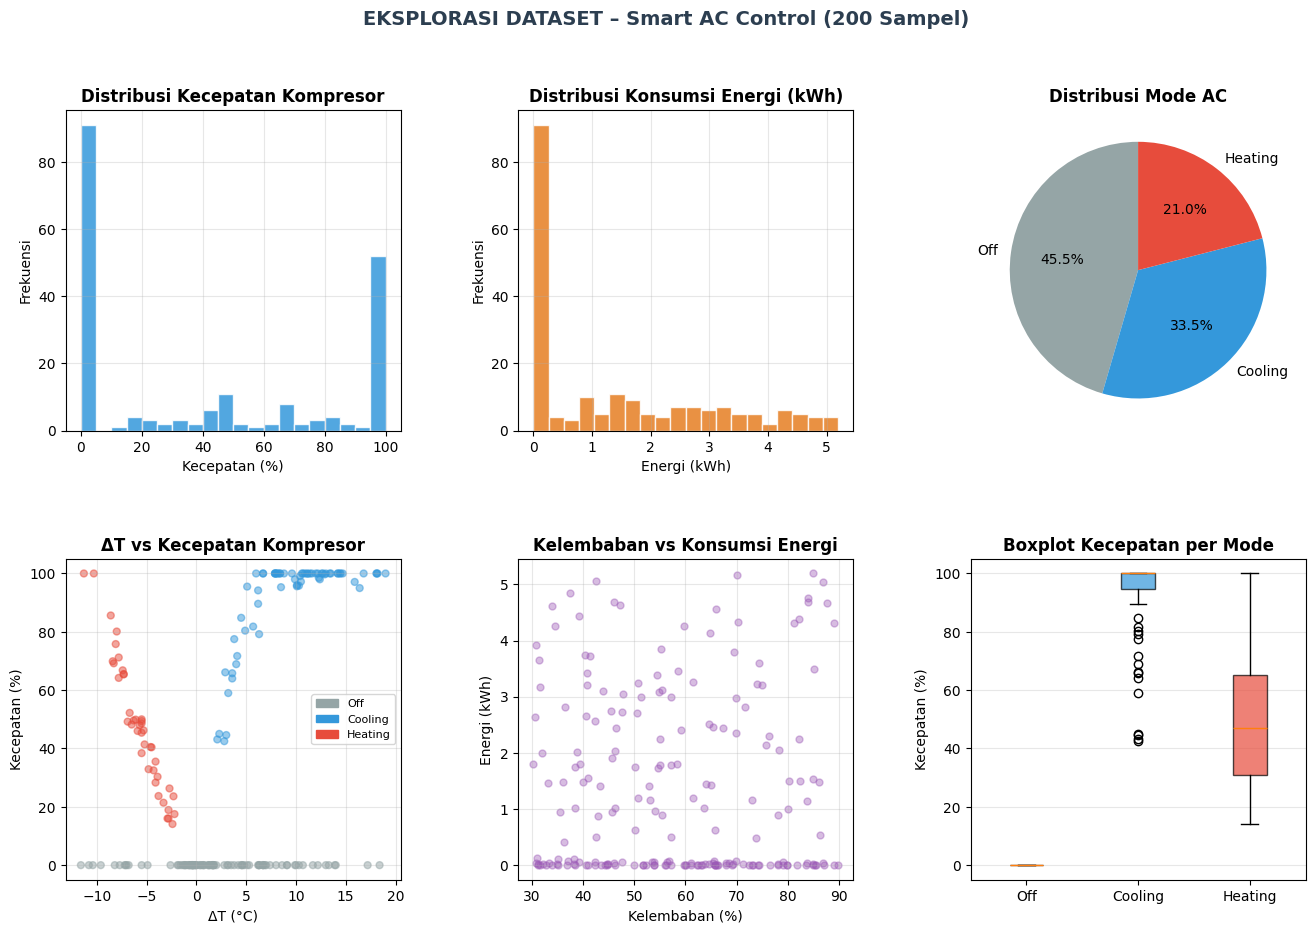

✅ EDA plot disimpan → artifacts/dataset_eda.png


In [5]:
fig = plt.figure(figsize=(16, 10))
gs  = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('EKSPLORASI DATASET – Smart AC Control (200 Sampel)', fontsize=14,
             fontweight='bold', color='#2c3e50')

# Plot 1: Distribusi Kecepatan Kompresor
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['Kecepatan_Kompresor'], bins=20, color='#3498db', edgecolor='white', alpha=0.85)
ax1.set_title('Distribusi Kecepatan Kompresor', fontweight='bold')
ax1.set_xlabel('Kecepatan (%)'); ax1.set_ylabel('Frekuensi')
ax1.grid(True, alpha=0.3)

# Plot 2: Distribusi Konsumsi Energi
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df['Konsumsi_Energi'], bins=20, color='#e67e22', edgecolor='white', alpha=0.85)
ax2.set_title('Distribusi Konsumsi Energi (kWh)', fontweight='bold')
ax2.set_xlabel('Energi (kWh)'); ax2.set_ylabel('Frekuensi')
ax2.grid(True, alpha=0.3)

# Plot 3: Pie Mode AC
ax3 = fig.add_subplot(gs[0, 2])
mode_counts = df['Mode_AC'].map({0:'Off', 1:'Cooling', 2:'Heating'}).value_counts()
ax3.pie(mode_counts.values, labels=mode_counts.index,
        autopct='%1.1f%%', colors=['#95a5a6','#3498db','#e74c3c'],
        startangle=90, textprops={'fontsize':10})
ax3.set_title('Distribusi Mode AC', fontweight='bold')

# Plot 4: Scatter ΔT vs Kecepatan
ax4 = fig.add_subplot(gs[1, 0])
dT_all = df['Temperatur_Ruangan'] - df['Target_Suhu']
colors_mode = df['Mode_AC'].map({0:'#95a5a6', 1:'#3498db', 2:'#e74c3c'})
ax4.scatter(dT_all, df['Kecepatan_Kompresor'], c=colors_mode, alpha=0.5, s=25)
ax4.set_title('ΔT vs Kecepatan Kompresor', fontweight='bold')
ax4.set_xlabel('ΔT (°C)'); ax4.set_ylabel('Kecepatan (%)')
ax4.grid(True, alpha=0.3)
handles = [mpatches.Patch(color=c, label=l) for c, l in [('#95a5a6','Off'),('#3498db','Cooling'),('#e74c3c','Heating')]]
ax4.legend(handles=handles, fontsize=8)

# Plot 5: Scatter Kelembaban vs Energi
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(df['Kelembaban'], df['Konsumsi_Energi'], c='#9b59b6', alpha=0.4, s=25)
ax5.set_title('Kelembaban vs Konsumsi Energi', fontweight='bold')
ax5.set_xlabel('Kelembaban (%)'); ax5.set_ylabel('Energi (kWh)')
ax5.grid(True, alpha=0.3)

# Plot 6: Boxplot Kecepatan per Mode
ax6 = fig.add_subplot(gs[1, 2])
data_box = [df[df['Mode_AC']==m]['Kecepatan_Kompresor'].values for m in [0, 1, 2]]
bp = ax6.boxplot(data_box, labels=['Off','Cooling','Heating'],
                 patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], ['#95a5a6','#3498db','#e74c3c']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax6.set_title('Boxplot Kecepatan per Mode', fontweight='bold')
ax6.set_ylabel('Kecepatan (%)'); ax6.grid(True, alpha=0.3, axis='y')

plt.savefig('artifacts/dataset_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plot disimpan → artifacts/dataset_eda.png")

---
## SECTION 2: FUNGSI UTILITY GLOBAL
### 2.1 – Fungsi MF, Evaluasi Metrik, dan Hitung Energi

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# FUNGSI TRAPEZOID MF
# ─────────────────────────────────────────────────────────────────────────────
def trapezoid_mf(x, a, b, c, d):
    """Trapezoid membership function (vectorized)."""
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    y = np.where((x > a) & (x <= b), (x - a) / (b - a + 1e-12), y)
    y = np.where((x > b) & (x <= c), 1.0, y)
    y = np.where((x > c) & (x <  d), (d - x) / (d - c + 1e-12), y)
    y = np.where(b == a, np.where(x == a, 1.0, y), y)
    return np.clip(y, 0, 1)

# ─────────────────────────────────────────────────────────────────────────────
# FUNGSI EVALUASI METRIK PERFORMA
# ─────────────────────────────────────────────────────────────────────────────
def evaluate_model(y_true, y_pred, label='Model', verbose=True):
    """Hitung MSE, RMSE, MAE, R² dan tampilkan tabel."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mse    = float(mean_squared_error(y_true, y_pred))
    rmse   = float(np.sqrt(mse))
    mae    = float(mean_absolute_error(y_true, y_pred))
    r2     = float(r2_score(y_true, y_pred))
    if verbose:
        print(f"  {'Metrik':<8} {'Nilai':>10}")
        print(f"  {'─'*22}")
        print(f"  {'MSE':<8} {mse:>10.4f}")
        print(f"  {'RMSE':<8} {rmse:>10.4f}")
        print(f"  {'MAE':<8} {mae:>10.4f}")
        print(f"  {'R²':<8} {r2:>10.4f}")
    return {'label': label, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

# ─────────────────────────────────────────────────────────────────────────────
# FUNGSI KALKULASI KONSUMSI ENERGI (dari prediksi kecepatan)
# ─────────────────────────────────────────────────────────────────────────────
P_RATED_KW = 2.5  # Daya nominal AC 1 PK (kW)

def compute_energy_from_speed(pred_speed_array, df_source):
    """
    Hitung konsumsi energi (kWh) dari array prediksi kecepatan kompresor.
    Menggunakan Durasi_Operasi dan Kelembaban dari dataset.

    Formula: E = (speed/100) * P_rated * t_operasi * (1 + 0.1 * Kl/50)
    """
    pred_speed = np.asarray(pred_speed_array)
    durations  = df_source['Durasi_Operasi'].values
    humidity   = df_source['Kelembaban'].values
    hum_factor = 1.0 + 0.1 * (humidity / 50.0)
    energy     = (pred_speed / 100.0) * P_RATED_KW * durations * hum_factor
    return np.maximum(energy, 0.0)

def energy_summary(pred_speed, df_source, label):
    """Print ringkasan konsumsi energi."""
    energy = compute_energy_from_speed(pred_speed, df_source)
    total  = float(np.sum(energy))
    mean_  = float(np.mean(energy))
    print(f"  ⚡ Energi Total ({label:<20}) : {total:8.3f} kWh")
    print(f"  ⚡ Energi Rata-rata           : {mean_:8.4f} kWh/sesi")
    return {'label': label, 'total_energy_kwh': total, 'mean_energy_kwh': mean_}

print("✅ Fungsi utility global siap (trapezoid_mf, evaluate_model, compute_energy_from_speed)")

✅ Fungsi utility global siap (trapezoid_mf, evaluate_model, compute_energy_from_speed)


---
## SECTION 3: TAHAP 1 – HUMAN INTUITION (MANUAL SUGENO FIS)

### 3.1 – Definisi Parameter MF Manual

**Sistem Sugeno Zero-Order** dengan input:
- `ΔT` = Temperatur_Ruangan − Target_Suhu (range: −10..+15 °C)
- `Kelembaban` (range: 30..90 %)
- `Okupansi` sebagai hard gate (0 → output = 0)

**15 Rules:** kombinasi 5 set ΔT × 3 set Kelembaban

In [7]:
print("=" * 65)
print("  TAHAP 1: HUMAN INTUITION – MANUAL FUZZY INFERENCE SYSTEM")
print("=" * 65)

MANUAL_MF_PARAMS = {
    'delta_T': {
        'sangat_dingin' : [-10, -10,  -7,  -4],
        'dingin'        : [ -6,  -4,  -2,   0],
        'nyaman'        : [ -2,   0,   0,   2],
        'panas'         : [  0,   2,   4,   6],
        'sangat_panas'  : [  4,   7,  15,  15],
    },
    'kelembaban': {
        'rendah'   : [30, 30, 45, 55],
        'sedang'   : [45, 55, 65, 75],
        'tinggi'   : [65, 75, 90, 90],
    },
    'kecepatan': {
        'off'    :   0,
        'rendah' :  25,
        'sedang' :  50,
        'tinggi' :  75,
        'max'    : 100,
    }
}

# Rule Base (15 rules) – Sugeno Zero-Order
RULE_TABLE = {
    ('sangat_dingin', 'rendah')  : 'rendah',
    ('sangat_dingin', 'sedang')  : 'rendah',
    ('sangat_dingin', 'tinggi')  : 'sedang',
    ('dingin',        'rendah')  : 'off',
    ('dingin',        'sedang')  : 'rendah',
    ('dingin',        'tinggi')  : 'sedang',
    ('nyaman',        'rendah')  : 'off',
    ('nyaman',        'sedang')  : 'off',
    ('nyaman',        'tinggi')  : 'rendah',
    ('panas',         'rendah')  : 'sedang',
    ('panas',         'sedang')  : 'tinggi',
    ('panas',         'tinggi')  : 'tinggi',
    ('sangat_panas',  'rendah')  : 'tinggi',
    ('sangat_panas',  'sedang')  : 'max',
    ('sangat_panas',  'tinggi')  : 'max',
}

def manual_fis_predict(row, params=None):
    """Manual Sugeno FIS – Weighted Average defuzzification."""
    if params is None:
        params = MANUAL_MF_PARAMS
    if row['Okupansi'] == 0:
        return 0.0

    dT = row['Temperatur_Ruangan'] - row['Target_Suhu']
    Kl = row['Kelembaban']

    mu_dT = {k: float(trapezoid_mf(np.array([dT]), *v)[0])
             for k, v in params['delta_T'].items()}
    mu_kl = {k: float(trapezoid_mf(np.array([Kl]), *v)[0])
             for k, v in params['kelembaban'].items()}

    total_firing = 0.0
    weighted_sum = 0.0
    for (dT_lbl, kl_lbl), speed_lbl in RULE_TABLE.items():
        output_val  = params['kecepatan'][speed_lbl]
        firing      = mu_dT[dT_lbl] * mu_kl[kl_lbl]
        weighted_sum += firing * output_val
        total_firing += firing

    if total_firing < 1e-12:
        return 0.0
    return float(np.clip(weighted_sum / total_firing, 0, 100))

print("✅ Manual FIS didefinisikan")
print(f"   Jumlah Rules  : {len(RULE_TABLE)}")
print(f"   MF delta_T    : {list(MANUAL_MF_PARAMS['delta_T'].keys())}")
print(f"   MF kelembaban : {list(MANUAL_MF_PARAMS['kelembaban'].keys())}")

  TAHAP 1: HUMAN INTUITION – MANUAL FUZZY INFERENCE SYSTEM
✅ Manual FIS didefinisikan
   Jumlah Rules  : 15
   MF delta_T    : ['sangat_dingin', 'dingin', 'nyaman', 'panas', 'sangat_panas']
   MF kelembaban : ['rendah', 'sedang', 'tinggi']


### 3.2 – Prediksi & Evaluasi Manual FIS

In [8]:
print("🔄 Menjalankan Manual FIS pada 200 baris dataset...")
df['Pred_Manual_FIS'] = df.apply(manual_fis_predict, axis=1)

# Konsumsi Energi: prediksi vs aktual
df['Energy_Manual_FIS'] = compute_energy_from_speed(df['Pred_Manual_FIS'], df)

print(f"   Min={df['Pred_Manual_FIS'].min():.1f}  Max={df['Pred_Manual_FIS'].max():.1f}")
print()
print("EVALUASI – TAHAP 1: Manual FIS (Kecepatan Kompresor)")
print("─" * 40)
metrics_manual = evaluate_model(
    df['Kecepatan_Kompresor'], df['Pred_Manual_FIS'], label='Manual FIS'
)
print()
print("EVALUASI KONSUMSI ENERGI – TAHAP 1:")
print("─" * 40)
energy_actual_stats  = energy_summary(df['Kecepatan_Kompresor'], df, 'Aktual')
energy_manual_stats  = energy_summary(df['Pred_Manual_FIS'],     df, 'Manual FIS')
energy_err_manual    = float(np.mean(np.abs(df['Energy_Manual_FIS'] - df['Konsumsi_Energi'])))
print(f"  ⚡ MAE Konsumsi Energi (Manual FIS) : {energy_err_manual:.4f} kWh")

🔄 Menjalankan Manual FIS pada 200 baris dataset...
   Min=0.0  Max=100.0

EVALUASI – TAHAP 1: Manual FIS (Kecepatan Kompresor)
────────────────────────────────────────
  Metrik        Nilai
  ──────────────────────
  MSE        840.9971
  RMSE        28.9999
  MAE         16.3971
  R²           0.5347

EVALUASI KONSUMSI ENERGI – TAHAP 1:
────────────────────────────────────────
  ⚡ Energi Total (Aktual              ) :  280.093 kWh
  ⚡ Energi Rata-rata           :   1.4005 kWh/sesi
  ⚡ Energi Total (Manual FIS          ) :  247.750 kWh
  ⚡ Energi Rata-rata           :   1.2388 kWh/sesi
  ⚡ MAE Konsumsi Energi (Manual FIS) : 0.5980 kWh


### 3.3 – Visualisasi MF Manual (BEFORE Tuning)

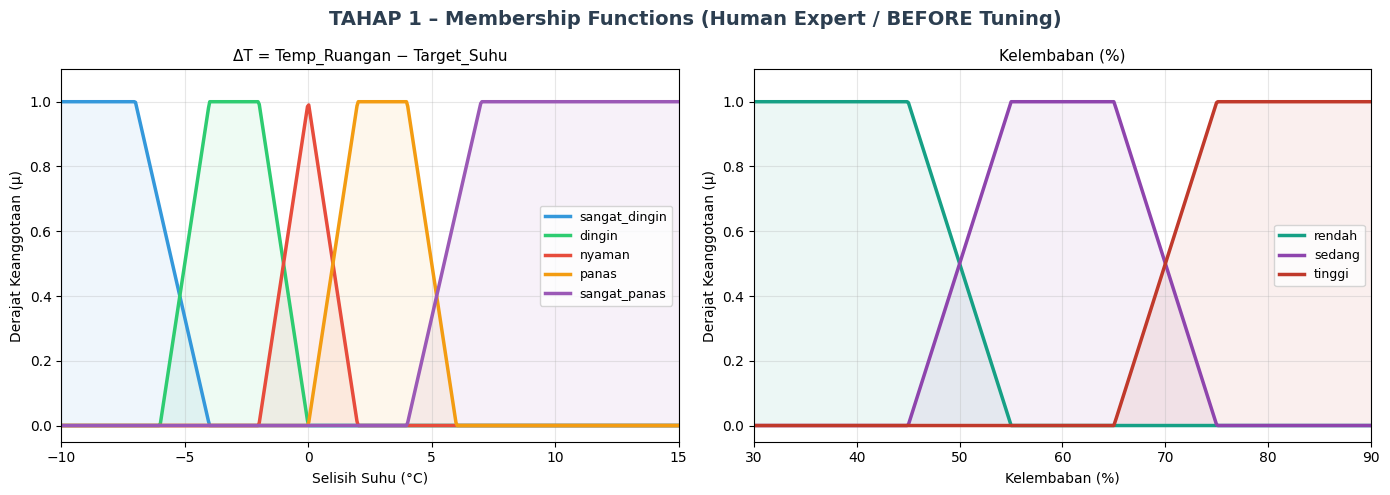

✅ Grafik MF manual disimpan → artifacts/mf_manual_before.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TAHAP 1 – Membership Functions (Human Expert / BEFORE Tuning)',
             fontsize=14, fontweight='bold', color='#2c3e50')

x_dT = np.linspace(-10, 15, 500)
x_kl = np.linspace(30, 90, 500)
colors_dT = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

ax1 = axes[0]
for idx, lbl in enumerate(['sangat_dingin','dingin','nyaman','panas','sangat_panas']):
    y = trapezoid_mf(x_dT, *MANUAL_MF_PARAMS['delta_T'][lbl])
    ax1.plot(x_dT, y, color=colors_dT[idx], linewidth=2.5, label=lbl)
    ax1.fill_between(x_dT, y, alpha=0.08, color=colors_dT[idx])
ax1.set_title('ΔT = Temp_Ruangan − Target_Suhu', fontsize=11)
ax1.set_xlabel('Selisih Suhu (°C)'); ax1.set_ylabel('Derajat Keanggotaan (μ)')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
ax1.set_xlim(-10, 15); ax1.set_ylim(-0.05, 1.1)

ax2 = axes[1]
c2 = ['#16a085', '#8e44ad', '#c0392b']
for idx, lbl in enumerate(['rendah','sedang','tinggi']):
    y = trapezoid_mf(x_kl, *MANUAL_MF_PARAMS['kelembaban'][lbl])
    ax2.plot(x_kl, y, color=c2[idx], linewidth=2.5, label=lbl)
    ax2.fill_between(x_kl, y, alpha=0.08, color=c2[idx])
ax2.set_title('Kelembaban (%)', fontsize=11)
ax2.set_xlabel('Kelembaban (%)'); ax2.set_ylabel('Derajat Keanggotaan (μ)')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
ax2.set_xlim(30, 90); ax2.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.savefig('artifacts/mf_manual_before.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik MF manual disimpan → artifacts/mf_manual_before.png")

---
## SECTION 4: TAHAP 2 – EVOLUTIONARY TUNING (GENETIC ALGORITHM)

### 4.1 – Konfigurasi GA

| Parameter GA | Nilai | Alasan |
|---|---|---|
| Representasi | Real-valued chromosome (16 float) | Parameter trapezoid MF langsung |
| Populasi | 60 (50% manual seed + 50% random) | Balance eksplorasi-eksploitasi |
| Generasi | 120 | Konvergensi stabil |
| Crossover | Blend (cxBlend, α=0.3) | Smooth interpolasi parameter |
| Mutasi | Gaussian dinamis (cosine annealing σ) | Eksplor di awal, eksploitasi di akhir |
| Seleksi | Tournament (k=3) | Pressure seleksi moderat |
| Elitism | 5 individu terbaik | Cegah kehilangan solusi terbaik |
| Anti-stagnasi | Random restart 20% populasi jika stuck 15 gen | Hindari local optima |

**Kromosom (16 gen):** `[dT_panas(4), dT_sangat_panas(4), kl_sedang(4), kl_tinggi(4)]`

In [10]:
print("=" * 65)
print("  TAHAP 2: EVOLUTIONARY TUNING – GENETIC ALGORITHM (GA)")
print("=" * 65)

def chromosome_to_mf(chrom):
    """Konversi kromosom 16-float ke parameter MF."""
    c = chrom
    params = copy.deepcopy(MANUAL_MF_PARAMS)
    params['delta_T']['panas']        = sorted(c[0:4])
    params['delta_T']['sangat_panas'] = sorted(c[4:8])
    params['kelembaban']['sedang']    = sorted(c[8:12])
    params['kelembaban']['tinggi']    = sorted(c[12:16])
    return params

def trapezoid_validity_penalty(chrom):
    """Penalti fisik: MF harus tetap logis (tidak degenerate/terlalu sempit)."""
    penalty = 0.0
    for g in [chrom[0:4], chrom[4:8]]:
        s = sorted(g)
        if s[3] - s[0] < 1.5: penalty += 5.0
        if s[1] - s[0] < 0.3 or s[3] - s[2] < 0.3: penalty += 2.0
    panas_cd  = sorted(chrom[0:4])[2:]
    spanas_ab = sorted(chrom[4:8])[:2]
    penalty  += max(0, panas_cd[1] - spanas_ab[0]) * 1.5
    for g in [chrom[8:12], chrom[12:16]]:
        s = sorted(g)
        if s[3] - s[0] < 3.0: penalty += 5.0
    return penalty

def evaluate_chromosome(individual):
    """Fitness: minimasi (RMSE + penalti validitas MF)."""
    params = chromosome_to_mf(individual)
    preds  = df.apply(lambda row: manual_fis_predict(row, params), axis=1).values
    rmse   = float(np.sqrt(mean_squared_error(df['Kecepatan_Kompresor'].values, preds)))
    return (rmse + trapezoid_validity_penalty(individual),)

# ── Setup DEAP toolbox ──────────────────────────────────────────────────────
if hasattr(creator, 'FitnessMin'): del creator.FitnessMin
if hasattr(creator, 'Individual'): del creator.Individual
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)
toolbox = base.Toolbox()

def init_individual_from_manual():
    base_chrom = [0, 2, 4, 6,  4, 7, 11, 15,  45, 55, 65, 75,  65, 75, 85, 90]
    noise = np.random.normal(0, 0.8, 16)
    lo = [-12]*8 + [28]*8
    hi = [15]*8  + [90]*8
    return creator.Individual(
        [float(np.clip(base_chrom[i]+noise[i], lo[i], hi[i])) for i in range(16)])

def init_individual_random():
    lo = [-12,-10,-7,-5,  0, 4, 8,11,  30,38,45,55,  50,60,70,80]
    hi = [ -4, -1, 0, 3,  3, 7,13,15,  45,58,68,80,  68,80,88,90]
    return creator.Individual([float(np.random.uniform(lo[i], hi[i])) for i in range(16)])

def init_population_mixed(n):
    return [init_individual_from_manual() if i < n//2
            else init_individual_random() for i in range(n)]

toolbox.register("individual", init_individual_from_manual)
toolbox.register("population", init_population_mixed)
toolbox.register("evaluate",   evaluate_chromosome)
toolbox.register("mate",       tools.cxBlend, alpha=0.3)
toolbox.register("mutate",     tools.mutGaussian, mu=0, sigma=1.0, indpb=0.25)
toolbox.register("select",     tools.selTournament, tournsize=3)

print("✅ DEAP Toolbox dikonfigurasi")

  TAHAP 2: EVOLUTIONARY TUNING – GENETIC ALGORITHM (GA)
✅ DEAP Toolbox dikonfigurasi


### 4.2 – Fungsi Run GA (Enhanced)

In [11]:
def run_ga(pop_size=60, n_gen=120, cxpb=0.75,
           mutpb_init=0.35, mutpb_final=0.10,
           sigma_init=1.2, sigma_final=0.15,
           n_elite=5, stagnation_limit=15,
           verbose=True):
    """
    Enhanced GA dengan:
    - Cosine Annealing (sigma & mutpb decay)
    - Elitism (top-N selalu dipertahankan)
    - Random Restart Injection jika stagnasi > stagnation_limit generasi
    """
    pop = init_population_mixed(pop_size)
    hof = tools.HallOfFame(n_elite)
    history = {'min': [], 'avg': [], 'sigma': [], 'stagnation_events': []}
    best_ever, stagnation_counter = float('inf'), 0

    if verbose:
        print(f"  {'Gen':>4}  {'Min Fit':>10}  {'Avg Fit':>10}  {'σ':>8}  {'Stagnation':>10}")
        print(f"  {'─'*60}")

    for ind in pop:
        ind.fitness.values = toolbox.evaluate(ind)
    hof.update(pop)

    for gen in range(1, n_gen + 1):
        progress   = gen / n_gen
        cos_factor = 0.5 * (1 + np.cos(np.pi * progress))
        sigma_cur  = sigma_final + (sigma_init  - sigma_final)  * cos_factor
        mutpb_cur  = mutpb_final + (mutpb_init  - mutpb_final)  * cos_factor

        elite_inds = [toolbox.clone(ind) for ind in hof]
        offspring  = [toolbox.clone(ind) for ind in toolbox.select(pop, k=pop_size)]

        for i in range(0, len(offspring)-1, 2):
            if random.random() < cxpb:
                toolbox.mate(offspring[i], offspring[i+1])
                del offspring[i].fitness.values, offspring[i+1].fitness.values

        for ind in offspring:
            if random.random() < mutpb_cur:
                tools.mutGaussian(ind, mu=0, sigma=sigma_cur, indpb=0.20)
                del ind.fitness.values

        for ind in offspring:
            if not ind.fitness.valid:
                ind.fitness.values = toolbox.evaluate(ind)

        pop = tools.selBest(offspring + elite_inds, k=pop_size)
        hof.update(pop)

        gen_min = min(ind.fitness.values[0] for ind in pop)
        gen_avg = np.mean([ind.fitness.values[0] for ind in pop])

        if gen_min < best_ever - 1e-6:
            best_ever, stagnation_counter = gen_min, 0
        else:
            stagnation_counter += 1

        stag_event = False
        if stagnation_counter >= stagnation_limit:
            n_restart = int(pop_size * 0.20)
            restart   = [init_individual_random() for _ in range(n_restart)]
            for ind in restart:
                ind.fitness.values = toolbox.evaluate(ind)
            pop = tools.selBest(pop, k=pop_size - n_restart) + restart
            random.shuffle(pop)
            hof.update(pop)
            stagnation_counter = 0
            stag_event = True

        history['min'].append(gen_min)
        history['avg'].append(gen_avg)
        history['sigma'].append(sigma_cur)
        history['stagnation_events'].append(gen if stag_event else None)

        if verbose and (gen % 10 == 0 or gen == 1):
            stag_flag = '⚡RESTART' if stag_event else ''
            print(f"  {gen:>4}  {gen_min:>10.4f}  {gen_avg:>10.4f}  {sigma_cur:>8.3f}  {stag_flag}")

    return hof[0], history

print("✅ Fungsi run_ga siap")

✅ Fungsi run_ga siap


### 4.3 – Jalankan GA Utama (Pop=60, Gen=120)

In [12]:
random.seed(42); np.random.seed(42)
print("Menjalankan GA utama (population=60, generations=120)...")
t0 = time.time()
ga_best, ga_history_main = run_ga(pop_size=60, n_gen=120, verbose=True)
ga_runtime = time.time() - t0
print(f"\n✅ GA selesai! Best fitness: {ga_best.fitness.values[0]:.4f}")
print(f"   Waktu eksekusi : {ga_runtime:.1f} detik")

Menjalankan GA utama (population=60, generations=120)...
   Gen     Min Fit     Avg Fit         σ  Stagnation
  ────────────────────────────────────────────────────────────
     1     29.2309     32.8072     1.200  
    10     21.5966     25.6635     1.182  
    20     19.2702     19.9577     1.130  
    30     19.0266     19.5191     1.046  
    40     18.9214     18.9811     0.938  
    50     18.6282     18.8289     0.811  
    60     18.4320     18.5886     0.675  
    70     18.3817     18.4165     0.539  
    80     18.2845     18.3167     0.413  
    90     18.2125     18.2270     0.304  
   100     18.1708     18.1787     0.220  
   110     18.1331     18.1456     0.168  
   120     18.0945     18.1122     0.150  

✅ GA selesai! Best fitness: 18.0945
   Waktu eksekusi : 340.5 detik


### 4.4 – Evaluasi GA (Kecepatan & Energi)

In [13]:
ga_mf_params = chromosome_to_mf(ga_best)
df['Pred_GA_FIS']    = df.apply(lambda row: manual_fis_predict(row, ga_mf_params), axis=1)
df['Energy_GA_FIS']  = compute_energy_from_speed(df['Pred_GA_FIS'], df)

print("EVALUASI – TAHAP 2: GA-Tuned FIS (Kecepatan Kompresor)")
print("─" * 40)
metrics_ga = evaluate_model(
    df['Kecepatan_Kompresor'], df['Pred_GA_FIS'], label='GA-Tuned FIS'
)
print()
print("EVALUASI KONSUMSI ENERGI – TAHAP 2:")
print("─" * 40)
energy_ga_stats = energy_summary(df['Pred_GA_FIS'], df, 'GA-Tuned FIS')
energy_err_ga   = float(np.mean(np.abs(df['Energy_GA_FIS'] - df['Konsumsi_Energi'])))
print(f"  ⚡ MAE Konsumsi Energi (GA-Tuned)    : {energy_err_ga:.4f} kWh")

EVALUASI – TAHAP 2: GA-Tuned FIS (Kecepatan Kompresor)
────────────────────────────────────────
  Metrik        Nilai
  ──────────────────────
  MSE        327.4119
  RMSE        18.0945
  MAE          9.6530
  R²           0.8189

EVALUASI KONSUMSI ENERGI – TAHAP 2:
────────────────────────────────────────
  ⚡ Energi Total (GA-Tuned FIS        ) :  253.073 kWh
  ⚡ Energi Rata-rata           :   1.2654 kWh/sesi
  ⚡ MAE Konsumsi Energi (GA-Tuned)    : 0.3621 kWh


### 4.5 – Ablation Study LENGKAP: Variasi Population Size & Iterasi

> **Pertanyaan:** Apa yang terjadi jika Population Size atau jumlah Iterasi diubah secara ekstrem?  
> **Hipotesis:** Populasi kecil + iterasi sedikit → konvergensi prematur (stuck di local optima).

Ablation ini menguji **8 konfigurasi** berbeda dengan 3 metrik kunci:
- RMSE final (kualitas solusi)
- Generasi konvergensi (seberapa cepat mencapai threshold)
- Varian akhir (stabilitas)

In [14]:
print("=" * 65)
print("  ABLATION STUDY – GA PARAMETER SENSITIVITY")
print("=" * 65)
print()

# Target: 90% dari RMSE manual (sebagai threshold konvergensi)
target_threshold = metrics_manual['RMSE'] * 0.90
print(f"  Threshold konvergensi (90% of Manual RMSE) : {target_threshold:.4f}")
print()

# 8 konfigurasi: 4 variasi pop, 4 variasi gen (cross)
ablation_configs = [
    # Pop sangat kecil – konvergensi prematur
    {'pop': 5,   'gen': 15,  'label': 'Sangat Kecil  (Pop=5,  Gen=15)'},
    {'pop': 10,  'gen': 20,  'label': 'Kecil         (Pop=10, Gen=20)'},
    {'pop': 20,  'gen': 40,  'label': 'Kecil-Sedang  (Pop=20, Gen=40)'},
    # Konfigurasi sedang
    {'pop': 30,  'gen': 60,  'label': 'Sedang        (Pop=30, Gen=60)'},
    # Konfigurasi standar (referensi)
    {'pop': 60,  'gen': 100, 'label': 'Standar ★     (Pop=60, Gen=100)'},
    # Konfigurasi besar
    {'pop': 100, 'gen': 150, 'label': 'Besar         (Pop=100,Gen=150)'},
    # Pop besar tapi gen sedikit
    {'pop': 100, 'gen': 20,  'label': 'Pop↑ Gen↓     (Pop=100,Gen=20)'},
    # Pop kecil tapi gen besar
    {'pop': 5,   'gen': 200, 'label': 'Pop↓ Gen↑     (Pop=5,  Gen=200)'},
]

ablation_results   = []
ablation_histories = {}

print(f"  {'Konfigurasi':<36} {'RMSE':>8} {'Conv.Gen':>10} {'Var.Akhir':>12} {'Waktu(s)':>10}")
print(f"  {'─'*80}")

for cfg in ablation_configs:
    random.seed(42); np.random.seed(42)
    t_start = time.time()
    try:
        best_abl, hist_abl = run_ga(
            pop_size=cfg['pop'], n_gen=cfg['gen'],
            sigma_init=1.2, sigma_final=0.15,
            stagnation_limit=max(5, cfg['gen']//8),  # Disesuaikan dengan jumlah gen
            verbose=False
        )
        t_elapsed = time.time() - t_start

        rmse_abl = float(np.sqrt(mean_squared_error(
            df['Kecepatan_Kompresor'],
            df.apply(lambda r: manual_fis_predict(r, chromosome_to_mf(best_abl)), axis=1)
        )))

        # Generasi konvergensi: pertama kali fitness < threshold
        min_hist = hist_abl['min']
        conv_gen = next((i+1 for i, v in enumerate(min_hist) if v <= target_threshold), cfg['gen'])

        # Varian fitness pada 10 generasi terakhir (ukuran stabilitas)
        last_n    = min_hist[-10:] if len(min_hist) >= 10 else min_hist
        var_akhir = float(np.var(last_n))

        # Deteksi konvergensi prematur:
        # Jika 50% generasi awal sudah flatline (var < 0.01 di gen 1-10)
        early_hist = min_hist[:max(1, len(min_hist)//4)]
        premature  = float(np.var(early_hist)) < 0.01 and rmse_abl > target_threshold

        ablation_results.append({
            'label'      : cfg['label'],
            'pop'        : cfg['pop'],
            'gen'        : cfg['gen'],
            'rmse'       : rmse_abl,
            'conv_gen'   : conv_gen,
            'var_akhir'  : var_akhir,
            'waktu_s'    : round(t_elapsed, 2),
            'premature'  : premature,
        })
        ablation_histories[cfg['label']] = min_hist

        flag = '⚠️PREMATUR' if premature else ''
        print(f"  {cfg['label']:<36} {rmse_abl:>8.4f} {conv_gen:>10} {var_akhir:>12.5f} {t_elapsed:>10.1f}  {flag}")

    except Exception as e:
        print(f"  {cfg['label']:<36} ERROR: {e}")

with open('artifacts/ablation/ablation_results.json', 'w') as f:
    json.dump(ablation_results, f, indent=2)

print()
print("✅ Ablation results disimpan → artifacts/ablation/ablation_results.json")
print()
print("📋 ANALISIS KONVERGENSI PREMATUR:")
for r in ablation_results:
    if r['premature']:
        print(f"   ⚠️  {r['label']} → KONVERGENSI PREMATUR (RMSE={r['rmse']:.4f} > threshold={target_threshold:.4f})")

  ABLATION STUDY – GA PARAMETER SENSITIVITY

  Threshold konvergensi (90% of Manual RMSE) : 26.1000

  Konfigurasi                              RMSE   Conv.Gen    Var.Akhir   Waktu(s)
  ────────────────────────────────────────────────────────────────────────────────
  Sangat Kecil  (Pop=5,  Gen=15)        26.6892         15      0.19863        3.8  ⚠️PREMATUR
  Kecil         (Pop=10, Gen=20)        28.1042         20      0.00188        8.3  
  Kecil-Sedang  (Pop=20, Gen=40)        23.6309          9      0.00001       37.6  
  Sedang        (Pop=30, Gen=60)        18.9503         12      0.00011       89.4  
  Standar ★     (Pop=60, Gen=100)       18.2298          8      0.00038      275.5  
  Besar         (Pop=100,Gen=150)       11.9625          6      0.00010      680.2  
  Pop↑ Gen↓     (Pop=100,Gen=20)        19.0327          5      0.01232       96.4  
  Pop↓ Gen↑     (Pop=5,  Gen=200)       20.1044         28      0.00003       38.4  

✅ Ablation results disimpan → artifacts/ab

### 4.6 – Visualisasi Ablation Study (Comprehensive)

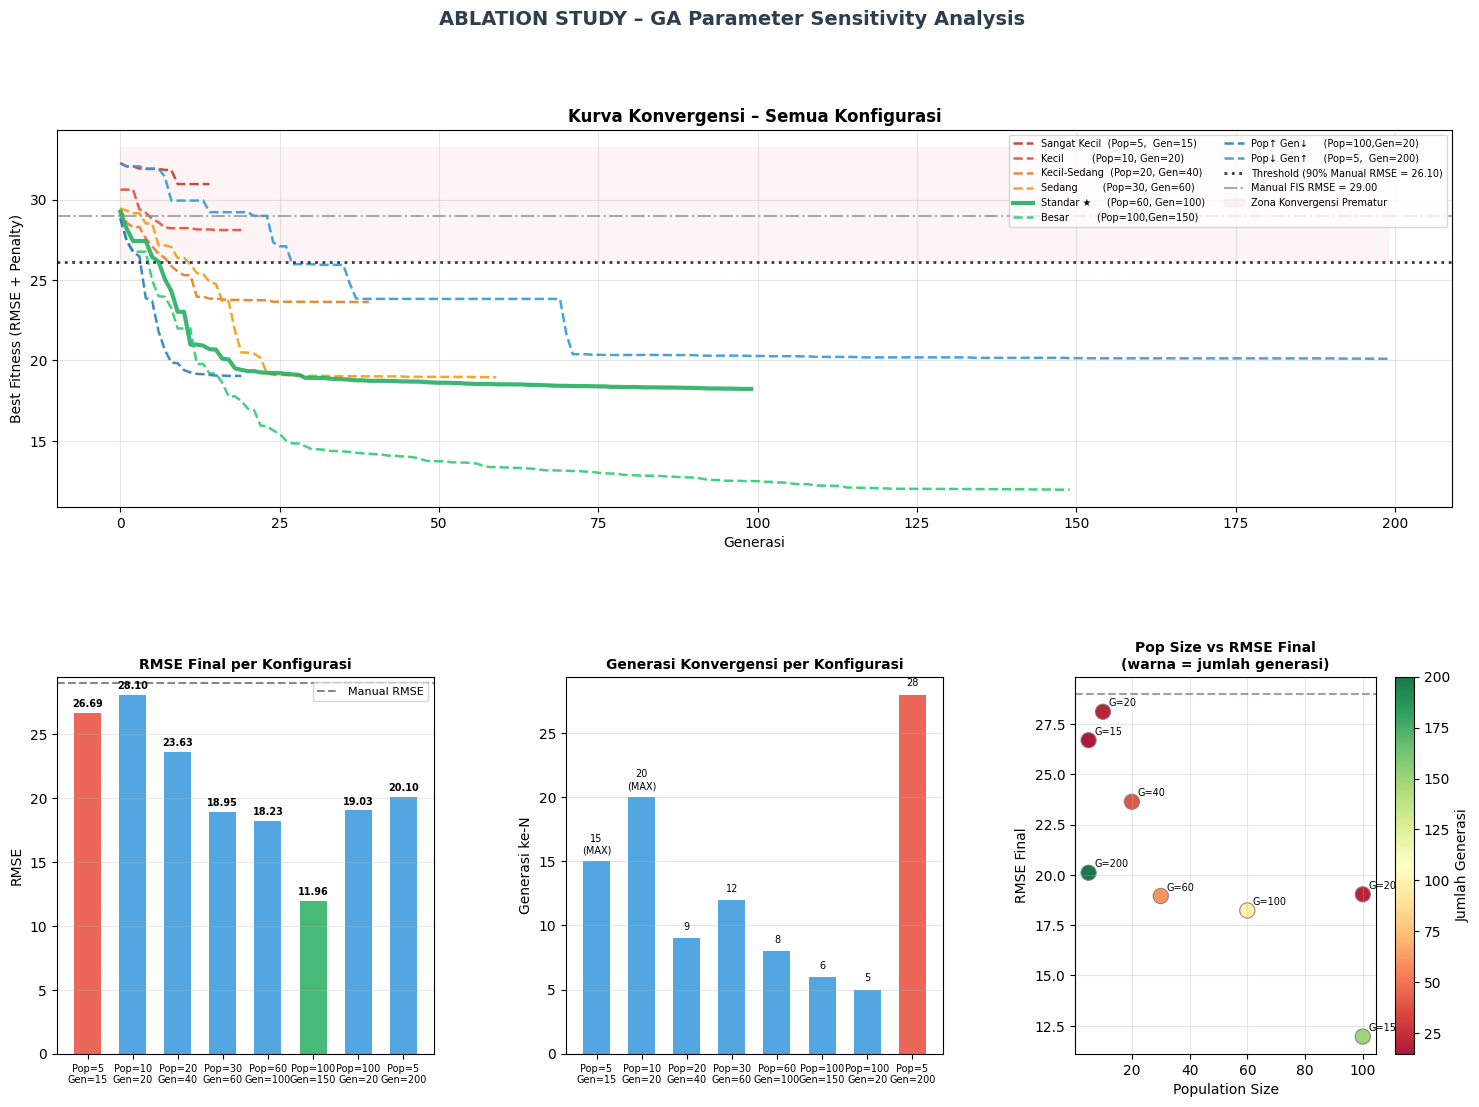

✅ Ablation study plot disimpan → artifacts/ablation/ablation_full_analysis.png


In [15]:
fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('ABLATION STUDY – GA Parameter Sensitivity Analysis',
             fontsize=14, fontweight='bold', color='#2c3e50')

abl_colors = ['#c0392b','#e74c3c','#e67e22','#f39c12',
              '#27ae60','#2ecc71','#2980b9','#3498db']

# ── Plot 1: Kurva konvergensi semua konfigurasi ──────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
for i, (lbl, hist) in enumerate(ablation_histories.items()):
    lw = 3.0 if '★' in lbl else 1.8
    ls = '-' if '★' in lbl else '--'
    ax1.plot(hist, color=abl_colors[i % len(abl_colors)],
             linewidth=lw, linestyle=ls, label=lbl, alpha=0.9)
ax1.axhline(y=target_threshold, color='#2c3e50', linestyle=':',
            linewidth=2, label=f'Threshold (90% Manual RMSE = {target_threshold:.2f})')
ax1.axhline(y=metrics_manual['RMSE'], color='#7f8c8d', linestyle='-.',
            linewidth=1.5, alpha=0.7, label=f'Manual FIS RMSE = {metrics_manual["RMSE"]:.2f}')
ax1.fill_between(range(max(len(h) for h in ablation_histories.values())),
                 target_threshold, ax1.get_ylim()[1] if ax1.get_ylim()[1] > target_threshold else target_threshold+5,
                 alpha=0.05, color='#e74c3c', label='Zona Konvergensi Prematur')
ax1.set_title('Kurva Konvergensi – Semua Konfigurasi', fontsize=12, fontweight='bold')
ax1.set_xlabel('Generasi'); ax1.set_ylabel('Best Fitness (RMSE + Penalty)')
ax1.legend(fontsize=7, loc='upper right', ncol=2); ax1.grid(True, alpha=0.3)

# ── Plot 2: Bar RMSE Final ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
labels_short = [f"Pop={r['pop']}\nGen={r['gen']}" for r in ablation_results]
rmse_vals    = [r['rmse'] for r in ablation_results]
bar_colors   = ['#27ae60' if r['rmse'] == min(rmse_vals) else
                '#e74c3c' if r['premature'] else '#3498db'
                for r in ablation_results]
bars = ax2.bar(range(len(ablation_results)), rmse_vals, color=bar_colors, alpha=0.85, width=0.6)
ax2.axhline(y=metrics_manual['RMSE'], color='#7f8c8d', linestyle='--', linewidth=1.5, label='Manual RMSE')
ax2.set_title('RMSE Final per Konfigurasi', fontweight='bold', fontsize=10)
ax2.set_xticks(range(len(ablation_results))); ax2.set_xticklabels(labels_short, fontsize=7)
ax2.set_ylabel('RMSE'); ax2.grid(True, alpha=0.3, axis='y'); ax2.legend(fontsize=8)
for bar, val in zip(bars, rmse_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.2f}',
             ha='center', va='bottom', fontsize=7, fontweight='bold')

# ── Plot 3: Bar Generasi Konvergensi ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
conv_vals = [r['conv_gen'] for r in ablation_results]
bar_c3    = ['#e74c3c' if v == max(conv_vals) else '#3498db' for v in conv_vals]
ax3.bar(range(len(ablation_results)), conv_vals, color=bar_c3, alpha=0.85, width=0.6)
ax3.set_title('Generasi Konvergensi per Konfigurasi', fontweight='bold', fontsize=10)
ax3.set_xticks(range(len(ablation_results))); ax3.set_xticklabels(labels_short, fontsize=7)
ax3.set_ylabel('Generasi ke-N'); ax3.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(conv_vals):
    max_gen = ablation_results[i]['gen']
    lbl = f'{v}\n(MAX)' if v == max_gen else str(v)
    ax3.text(i, v+0.5, lbl, ha='center', va='bottom', fontsize=7)

# ── Plot 4: Scatter Pop vs RMSE ──────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
pop_vals  = [r['pop'] for r in ablation_results]
gen_vals_ = [r['gen'] for r in ablation_results]
sc = ax4.scatter(pop_vals, rmse_vals, c=gen_vals_, cmap='RdYlGn', s=120, alpha=0.9,
                 edgecolors='gray', linewidths=0.8)
plt.colorbar(sc, ax=ax4, label='Jumlah Generasi')
ax4.axhline(y=metrics_manual['RMSE'], color='#7f8c8d', linestyle='--', linewidth=1.5, alpha=0.8)
ax4.set_title('Pop Size vs RMSE Final\n(warna = jumlah generasi)', fontweight='bold', fontsize=10)
ax4.set_xlabel('Population Size'); ax4.set_ylabel('RMSE Final')
ax4.grid(True, alpha=0.3)
for r in ablation_results:
    ax4.annotate(f"G={r['gen']}", (r['pop'], r['rmse']),
                 textcoords='offset points', xytext=(4, 4), fontsize=7)

plt.savefig('artifacts/ablation/ablation_full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Ablation study plot disimpan → artifacts/ablation/ablation_full_analysis.png")

### 4.7 – Simpan Hasil GA

In [16]:
# Simpan parameter MF GA terbaik
ga_mf_serializable = {
    var: {k: list(v) if isinstance(v, list) else float(v)
          for k, v in mf_dict.items()}
    for var, mf_dict in ga_mf_params.items()
}
with open('artifacts/ga_mf.json', 'w') as f:
    json.dump(ga_mf_serializable, f, indent=2)

# Simpan history GA
ga_history_serializable = {k: [float(x) for x in v if x is not None]
                            for k, v in ga_history_main.items()
                            if k != 'stagnation_events'}
ga_history_serializable['stagnation_gens'] = [
    int(x) for x in ga_history_main['stagnation_events'] if x is not None
]
with open('artifacts/ga_history.json', 'w') as f:
    json.dump(ga_history_serializable, f, indent=2)

print("✅ GA MF params   → artifacts/ga_mf.json")
print("✅ GA history     → artifacts/ga_history.json")
print("✅ Ablation JSON  → artifacts/ablation/ablation_results.json")

✅ GA MF params   → artifacts/ga_mf.json
✅ GA history     → artifacts/ga_history.json
✅ Ablation JSON  → artifacts/ablation/ablation_results.json


### 4.8 – Visualisasi Konvergensi GA Utama + Pergeseran MF

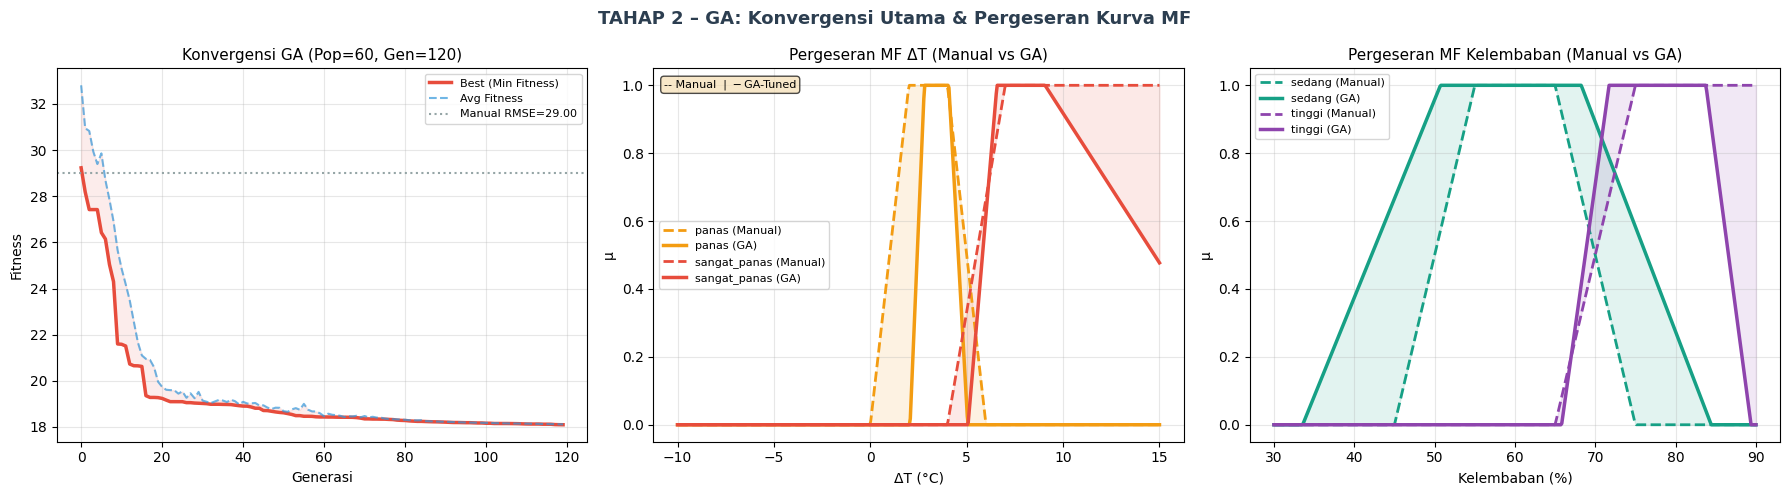

✅ Plot konvergensi & pergeseran MF GA → artifacts/ga_convergence_mf_shift.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('TAHAP 2 – GA: Konvergensi Utama & Pergeseran Kurva MF',
             fontsize=13, fontweight='bold', color='#2c3e50')

# Plot 1: Konvergensi GA utama
ax1 = axes[0]
ax1.plot(ga_history_main['min'], '#e74c3c', linewidth=2.5, label='Best (Min Fitness)')
ax1.plot(ga_history_main['avg'], '#3498db', linewidth=1.5, linestyle='--', alpha=0.7, label='Avg Fitness')
ax1.fill_between(range(len(ga_history_main['min'])),
                 ga_history_main['min'], ga_history_main['avg'], alpha=0.1, color='#e74c3c')
stag_gens = [i for i,x in enumerate(ga_history_main['stagnation_events']) if x is not None]
for sg in stag_gens:
    ax1.axvline(x=sg, color='#9b59b6', linestyle=':', linewidth=1.5, alpha=0.7)
if stag_gens:
    ax1.axvline(x=stag_gens[0], color='#9b59b6', linestyle=':', linewidth=1.5,
                alpha=0.7, label=f'Random Restart ({len(stag_gens)}x)')
ax1.axhline(y=metrics_manual['RMSE'], color='#95a5a6', linestyle=':', linewidth=1.5,
            label=f'Manual RMSE={metrics_manual["RMSE"]:.2f}')
ax1.set_title('Konvergensi GA (Pop=60, Gen=120)', fontsize=11)
ax1.set_xlabel('Generasi'); ax1.set_ylabel('Fitness')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# Plot 2: Pergeseran MF ΔT
x_dT = np.linspace(-10, 15, 500)
ax2 = axes[1]
for lbl, color in [('panas', '#f39c12'), ('sangat_panas', '#e74c3c')]:
    y_b = trapezoid_mf(x_dT, *MANUAL_MF_PARAMS['delta_T'][lbl])
    y_a = trapezoid_mf(x_dT, *ga_mf_params['delta_T'][lbl])
    ax2.plot(x_dT, y_b, color=color, linewidth=2,   linestyle='--', label=f'{lbl} (Manual)')
    ax2.plot(x_dT, y_a, color=color, linewidth=2.5, linestyle='-',  label=f'{lbl} (GA)')
    ax2.fill_between(x_dT, y_b, y_a, alpha=0.12, color=color)
ax2.set_title('Pergeseran MF ΔT (Manual vs GA)', fontsize=11)
ax2.set_xlabel('ΔT (°C)'); ax2.set_ylabel('μ')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
ax2.text(0.02, 0.97, '-- Manual  |  ─ GA-Tuned',
         transform=ax2.transAxes, fontsize=8, va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Plot 3: Pergeseran MF Kelembaban
x_kl = np.linspace(30, 90, 500)
ax3 = axes[2]
for lbl, color in [('sedang', '#16a085'), ('tinggi', '#8e44ad')]:
    y_b = trapezoid_mf(x_kl, *MANUAL_MF_PARAMS['kelembaban'][lbl])
    y_a = trapezoid_mf(x_kl, *ga_mf_params['kelembaban'][lbl])
    ax3.plot(x_kl, y_b, color=color, linewidth=2,   linestyle='--', label=f'{lbl} (Manual)')
    ax3.plot(x_kl, y_a, color=color, linewidth=2.5, linestyle='-',  label=f'{lbl} (GA)')
    ax3.fill_between(x_kl, y_b, y_a, alpha=0.12, color=color)
ax3.set_title('Pergeseran MF Kelembaban (Manual vs GA)', fontsize=11)
ax3.set_xlabel('Kelembaban (%)'); ax3.set_ylabel('μ')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/ga_convergence_mf_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot konvergensi & pergeseran MF GA → artifacts/ga_convergence_mf_shift.png")

---
## SECTION 5: TAHAP 3 – ANN TUNING (ANFIS)

### 5.1 – Arsitektur ANFIS

| Aspek | GA | ANFIS |
|---|---|---|
| Representasi MF | Trapezoid | Gaussian (differentiable) |
| Optimasi | Evolusioner (populasi) | Gradient descent (Adam) |
| Inisialisasi | Random + seeded | Konversi dari MF manual |
| Update | Parameter trapezoid {a,b,c,d} | Gaussian {c, σ} + consequents |

In [18]:
def trap_to_gauss(a, b, c, d):
    """Konversi trapezoid [a,b,c,d] → Gaussian (center, sigma)."""
    center = (b + c) / 2.0
    sigma  = max((d - a) / 4.0, 0.1)
    return center, sigma

class GaussianMF:
    """MF Gaussian dengan Adam optimizer built-in."""
    def __init__(self, c, sigma):
        self.c     = float(c)
        self.sigma = max(float(sigma), 1e-3)
        self.m_c = self.v_c = self.m_s = self.v_s = 0.0
        self.t   = 0

    def eval(self, x):
        return float(np.exp(-0.5 * ((x - self.c) / self.sigma) ** 2))

    def d_eval_dc(self, x):
        return self.eval(x) * (x - self.c) / (self.sigma ** 2)

    def d_eval_dsigma(self, x):
        return self.eval(x) * ((x - self.c) ** 2) / (self.sigma ** 3)

    def adam_update(self, grad_c, grad_sigma, lr=0.005, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        for attr, grad, m_key, v_key in [
            ('c',     grad_c,     'm_c', 'v_c'),
            ('sigma', grad_sigma, 'm_s', 'v_s')
        ]:
            m = beta1 * getattr(self, m_key) + (1 - beta1) * grad
            v = beta2 * getattr(self, v_key) + (1 - beta2) * grad ** 2
            setattr(self, m_key, m); setattr(self, v_key, v)
            m_hat = m / (1 - beta1 ** self.t)
            v_hat = v / (1 - beta2 ** self.t)
            step  = lr * m_hat / (np.sqrt(v_hat) + eps)
            new_val = float(np.clip(getattr(self, attr) + step,
                                   1e-3 if attr == 'sigma' else -np.inf, np.inf))
            setattr(self, attr, new_val)

print("✅ GaussianMF class siap")

✅ GaussianMF class siap


### 5.2 – ANFIS Tuner Class

In [19]:
class ANFIS_Tuner:
    """
    ANFIS (Adaptive Neuro-Fuzzy Inference System):
    - Layer 1: Fuzzification (Gaussian MF)
    - Layer 2: Rule Firing (product T-norm)
    - Layer 3: Normalization
    - Layer 4: Consequent (Sugeno zero-order)
    - Layer 5: Defuzzification (weighted sum)

    Fitur:
    - MinMaxScaler untuk stabilitas training
    - Hard gate Okupansi=0
    - Adam optimizer untuk MF + consequents
    - Gradient clipping (|g| ≤ 1.0)
    """
    def __init__(self, mf_params, lr_mf=0.005, lr_cons=0.05):
        self.lr_mf    = lr_mf
        self.lr_cons  = lr_cons
        self.scaler_X = MinMaxScaler()
        self.scaler_y = MinMaxScaler()

        # Inisialisasi MF Gaussian dari trapezoid manual
        self.deltaT_mf = {}
        for k, v in mf_params['delta_T'].items():
            c, s = trap_to_gauss(*v)
            self.deltaT_mf[k] = GaussianMF(c, s)

        self.kl_mf = {}
        for k, v in mf_params['kelembaban'].items():
            c, s = trap_to_gauss(*v)
            self.kl_mf[k] = GaussianMF(c, s)

        self.rule_labels = [
            (d, k, f"{d}_{k}")
            for d in self.deltaT_mf for k in self.kl_mf
        ]
        self.consequents = {lbl: 0.5 for _, _, lbl in self.rule_labels}
        self.cons_m = {lbl: 0.0 for _, _, lbl in self.rule_labels}
        self.cons_v = {lbl: 0.0 for _, _, lbl in self.rule_labels}
        self.cons_t = 0

    def _infer_scaled(self, x_sc):
        dT_s, Kl_s = x_sc[0], x_sc[1]
        strengths = np.array([
            self.deltaT_mf[d].eval(dT_s) * self.kl_mf[k].eval(Kl_s)
            for d, k, _ in self.rule_labels
        ])
        total  = strengths.sum()
        norm_w = np.ones(len(strengths)) / len(strengths) if total < 1e-12 else strengths / total
        output = float(sum(norm_w[i] * self.consequents[self.rule_labels[i][2]]
                           for i in range(len(self.rule_labels))))
        return output, strengths, norm_w, total

    def train(self, df_train, epochs=300):
        df_occ = df_train[df_train['Okupansi'] == 1].copy()
        dT     = (df_occ['Temperatur_Ruangan'] - df_occ['Target_Suhu']).values
        Kl     = df_occ['Kelembaban'].values
        X_raw  = np.column_stack([dT, Kl])
        y_raw  = df_occ['Kecepatan_Kompresor'].values.reshape(-1, 1)

        self.scaler_X.fit(X_raw)
        self.scaler_y.fit(y_raw)
        X_sc = self.scaler_X.transform(X_raw)
        y_sc = self.scaler_y.transform(y_raw).ravel()

        history = []
        beta1, beta2, eps_adam, clip_val = 0.9, 0.999, 1e-8, 1.0

        print(f"  Sampel training (occ=1) : {len(X_sc)}")
        print(f"  Jumlah rules            : {len(self.rule_labels)}")

        for epoch in range(epochs):
            idx = np.random.permutation(len(X_sc))
            epoch_loss = 0.0

            for i in idx:
                x, yt = X_sc[i], y_sc[i]
                out, strengths, norm_w, total = self._infer_scaled(x)
                err = yt - out
                epoch_loss += err ** 2

                # Update consequents (Adam)
                self.cons_t += 1
                for j, (_, _, lbl) in enumerate(self.rule_labels):
                    g = np.clip(err * norm_w[j], -clip_val, clip_val)
                    self.cons_m[lbl] = beta1 * self.cons_m[lbl] + (1 - beta1) * g
                    self.cons_v[lbl] = beta2 * self.cons_v[lbl] + (1 - beta2) * g ** 2
                    m_hat = self.cons_m[lbl] / (1 - beta1 ** self.cons_t)
                    v_hat = self.cons_v[lbl] / (1 - beta2 ** self.cons_t)
                    self.consequents[lbl] = float(np.clip(
                        self.consequents[lbl] + self.lr_cons * m_hat / (np.sqrt(v_hat) + eps_adam),
                        0.0, 1.0
                    ))

                # Update MF parameters (chain-rule)
                dT_s, Kl_s = x[0], x[1]
                for j, (d_name, k_name, lbl) in enumerate(self.rule_labels):
                    mf_dT  = self.deltaT_mf[d_name]
                    mf_Kl  = self.kl_mf[k_name]
                    mu_dT  = mf_dT.eval(dT_s)
                    mu_Kl  = mf_Kl.eval(Kl_s)
                    cons_j = self.consequents[lbl]
                    d_out_d_wj = (cons_j - out) / max(total, 1e-12)

                    gc_dT = np.clip(err * d_out_d_wj * mu_Kl * mf_dT.d_eval_dc(dT_s),     -clip_val, clip_val)
                    gs_dT = np.clip(err * d_out_d_wj * mu_Kl * mf_dT.d_eval_dsigma(dT_s), -clip_val, clip_val)
                    mf_dT.adam_update(gc_dT, gs_dT, lr=self.lr_mf)

                    gc_Kl = np.clip(err * d_out_d_wj * mu_dT * mf_Kl.d_eval_dc(Kl_s),     -clip_val, clip_val)
                    gs_Kl = np.clip(err * d_out_d_wj * mu_dT * mf_Kl.d_eval_dsigma(Kl_s), -clip_val, clip_val)
                    mf_Kl.adam_update(gc_Kl, gs_Kl, lr=self.lr_mf)

            mse = epoch_loss / len(X_sc)
            history.append(float(mse))
            if epoch % 60 == 0 or epoch == epochs - 1:
                print(f"  Epoch {epoch:3d}/{epochs-1} | MSE (normalized): {mse:.6f}")

        return history

    def predict(self, df_eval):
        df_eval = df_eval.reset_index(drop=True)
        preds   = np.zeros(len(df_eval))
        mask    = df_eval['Okupansi'].values == 1
        if mask.sum() > 0:
            df_act = df_eval[mask]
            dT     = (df_act['Temperatur_Ruangan'] - df_act['Target_Suhu']).values
            Kl     = df_act['Kelembaban'].values
            X_sc   = self.scaler_X.transform(np.column_stack([dT, Kl]))
            y_sc   = np.array([self._infer_scaled(x)[0] for x in X_sc])
            y_orig = self.scaler_y.inverse_transform(y_sc.reshape(-1,1)).ravel()
            preds[mask] = np.clip(y_orig, 0, 100)
        return preds

print("✅ ANFIS_Tuner class siap")

✅ ANFIS_Tuner class siap


### 5.3 – Training ANFIS

In [20]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train: {len(train_df)} | Test: {len(test_df)} | (Occ=1 train: {(train_df['Okupansi']==1).sum()})")
print()

np.random.seed(42)
anfis = ANFIS_Tuner(MANUAL_MF_PARAMS, lr_mf=0.005, lr_cons=0.05)

print("Training ANFIS (300 epoch)...")
t0 = time.time()
anfis_history = anfis.train(train_df, epochs=300)
anfis_runtime = time.time() - t0
print(f"\n✅ Training selesai! Waktu: {anfis_runtime:.1f} detik")

Train: 160 | Test: 40 | (Occ=1 train: 117)

Training ANFIS (300 epoch)...
  Sampel training (occ=1) : 117
  Jumlah rules            : 15
  Epoch   0/299 | MSE (normalized): 0.149132
  Epoch  60/299 | MSE (normalized): 0.014679
  Epoch 120/299 | MSE (normalized): 0.019417
  Epoch 180/299 | MSE (normalized): 0.023153
  Epoch 240/299 | MSE (normalized): 0.017288
  Epoch 299/299 | MSE (normalized): 0.016318

✅ Training selesai! Waktu: 49.6 detik


### 5.4 – Evaluasi ANFIS (Kecepatan & Energi)

In [21]:
# Evaluasi pada full dataset
df['Pred_ANN_FIS']   = anfis.predict(df)
df['Energy_ANN_FIS'] = compute_energy_from_speed(df['Pred_ANN_FIS'], df)

print("EVALUASI – TAHAP 3: ANFIS (Full Dataset)")
print("─" * 40)
metrics_ann = evaluate_model(
    df['Kecepatan_Kompresor'], df['Pred_ANN_FIS'], label='ANFIS'
)
print()

# Evaluasi test set
print("EVALUASI – TAHAP 3: ANFIS (Test Set)")
print("─" * 40)
metrics_ann_test = evaluate_model(
    test_df['Kecepatan_Kompresor'], anfis.predict(test_df), label='ANFIS (test)'
)
print()

print("EVALUASI KONSUMSI ENERGI – TAHAP 3:")
print("─" * 40)
energy_ann_stats = energy_summary(df['Pred_ANN_FIS'], df, 'ANFIS')
energy_err_ann   = float(np.mean(np.abs(df['Energy_ANN_FIS'] - df['Konsumsi_Energi'])))
print(f"  ⚡ MAE Konsumsi Energi (ANFIS)        : {energy_err_ann:.4f} kWh")

EVALUASI – TAHAP 3: ANFIS (Full Dataset)
────────────────────────────────────────
  Metrik        Nilai
  ──────────────────────
  MSE         86.1266
  RMSE         9.2804
  MAE          5.7250
  R²           0.9523

EVALUASI – TAHAP 3: ANFIS (Test Set)
────────────────────────────────────────
  Metrik        Nilai
  ──────────────────────
  MSE        104.1452
  RMSE        10.2052
  MAE          6.4012
  R²           0.9447

EVALUASI KONSUMSI ENERGI – TAHAP 3:
────────────────────────────────────────
  ⚡ Energi Total (ANFIS               ) :  306.596 kWh
  ⚡ Energi Rata-rata           :   1.5330 kWh/sesi
  ⚡ MAE Konsumsi Energi (ANFIS)        : 0.2108 kWh


### 5.5 – Visualisasi ANFIS: Loss Curve & Pergeseran MF

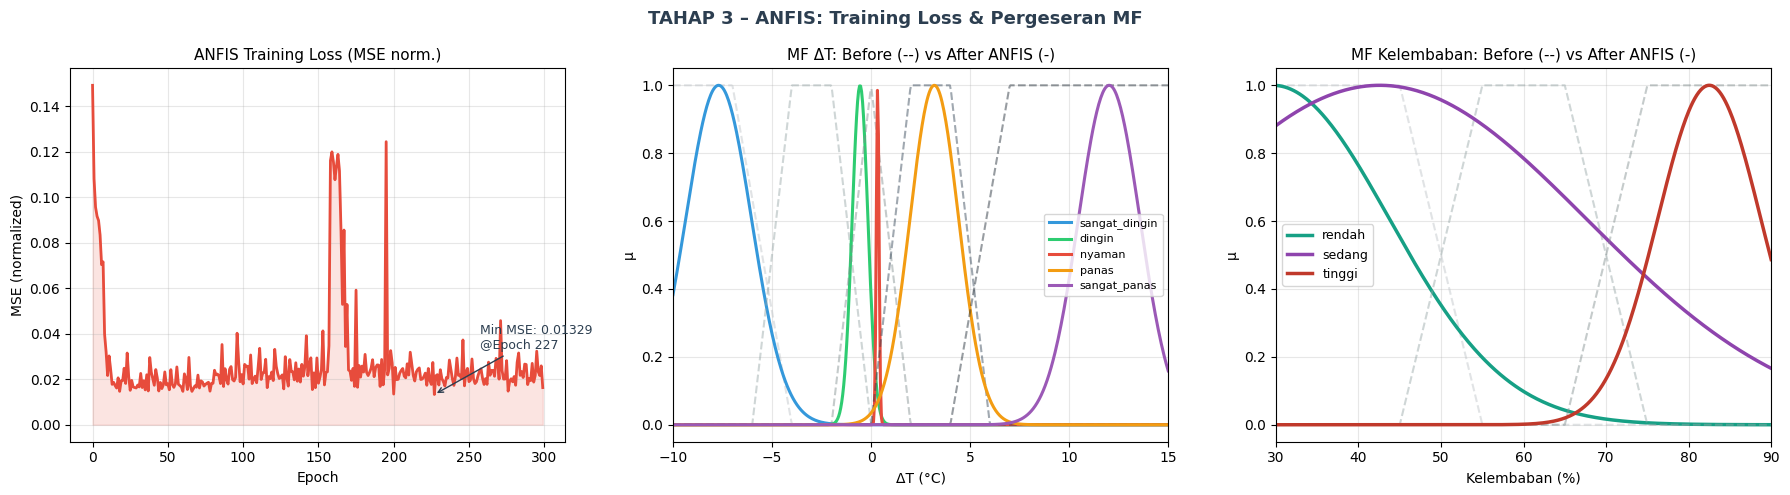

✅ ANFIS loss + MF plot → artifacts/anfis_loss_mf.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('TAHAP 3 – ANFIS: Training Loss & Pergeseran MF',
             fontsize=13, fontweight='bold', color='#2c3e50')

# Plot 1: ANFIS Loss Curve
ax1 = axes[0]
ax1.plot(anfis_history, color='#e74c3c', linewidth=2)
ax1.fill_between(range(len(anfis_history)), anfis_history, alpha=0.15, color='#e74c3c')
best_epoch = int(np.argmin(anfis_history))
best_mse   = min(anfis_history)
ax1.annotate(f'Min MSE: {best_mse:.5f}\n@Epoch {best_epoch}',
             xy=(best_epoch, best_mse), xytext=(best_epoch+30, best_mse+0.02),
             arrowprops=dict(arrowstyle='->', color='#2c3e50'),
             fontsize=9, color='#2c3e50')
ax1.set_title('ANFIS Training Loss (MSE norm.)', fontsize=11)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE (normalized)')
ax1.grid(True, alpha=0.3)

# Plot 2: MF ΔT Before vs After ANFIS
x_dT = np.linspace(-10, 15, 500)
ax2 = axes[1]
colors_a = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
colors_b = ['#bdc3c7', '#95a5a6', '#7f8c8d', '#2c3e50', '#1a252f']
for idx, (lbl, mf) in enumerate(anfis.deltaT_mf.items()):
    y_b = trapezoid_mf(x_dT, *MANUAL_MF_PARAMS['delta_T'][lbl])
    y_a = np.array([mf.eval(x) for x in x_dT])
    ax2.plot(x_dT, y_b, '--', alpha=0.45, color=colors_b[idx], linewidth=1.5)
    ax2.plot(x_dT, y_a, '-',  linewidth=2.2, color=colors_a[idx], label=lbl)
ax2.set_title('MF ΔT: Before (--) vs After ANFIS (-)', fontsize=11)
ax2.set_xlabel('ΔT (°C)'); ax2.set_ylabel('μ')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3); ax2.set_xlim(-10, 15)

# Plot 3: MF Kelembaban Before vs After ANFIS
x_kl = np.linspace(30, 90, 500)
ax3 = axes[2]
c_b3 = ['#bdc3c7', '#95a5a6', '#7f8c8d']
c_a3 = ['#16a085', '#8e44ad', '#c0392b']
for idx, (lbl, mf) in enumerate(anfis.kl_mf.items()):
    y_b = trapezoid_mf(x_kl, *MANUAL_MF_PARAMS['kelembaban'][lbl])
    y_a = np.array([mf.eval(x) for x in x_kl])
    ax3.plot(x_kl, y_b, '--', alpha=0.45, color=c_b3[idx], linewidth=1.5)
    ax3.plot(x_kl, y_a, '-',  linewidth=2.5, color=c_a3[idx], label=lbl)
ax3.set_title('MF Kelembaban: Before (--) vs After ANFIS (-)', fontsize=11)
ax3.set_xlabel('Kelembaban (%)'); ax3.set_ylabel('μ')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3); ax3.set_xlim(30, 90)

plt.tight_layout()
plt.savefig('artifacts/anfis_loss_mf.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ANFIS loss + MF plot → artifacts/anfis_loss_mf.png")

---
## SECTION 6: ANALISIS KOMPARATIF LENGKAP

### 6.1 – Tabel Metrik Perbandingan Ketiga Tahap

In [23]:
print("=" * 70)
print("  SECTION 6: ANALISIS KOMPARATIF – KECEPATAN KOMPRESOR & ENERGI")
print("=" * 70)

all_metrics = [metrics_manual, metrics_ga, metrics_ann]
comp_df = pd.DataFrame(all_metrics).set_index('label')

print("\nTABEL PERBANDINGAN METRIK KECEPATAN KOMPRESOR:")
print(comp_df[['MSE','RMSE','MAE','R2']].round(4).to_string())

print()
print("PENINGKATAN PERFORMA (vs Manual FIS):")
for m in [metrics_ga, metrics_ann]:
    rmse_imp = (metrics_manual['RMSE'] - m['RMSE']) / metrics_manual['RMSE'] * 100
    r2_imp   = m['R2'] - metrics_manual['R2']
    print(f"  {m['label']:<20} : RMSE ↓{rmse_imp:+.2f}%   R² Δ{r2_imp:+.4f}")

print()
print("⚡ TABEL PERBANDINGAN KONSUMSI ENERGI:")
energy_data = {
    'Model'               : ['Aktual', 'Manual FIS', 'GA-Tuned FIS', 'ANFIS'],
    'Total Energi (kWh)'  : [
        round(df['Konsumsi_Energi'].sum(), 3),
        round(df['Energy_Manual_FIS'].sum(), 3),
        round(df['Energy_GA_FIS'].sum(), 3),
        round(df['Energy_ANN_FIS'].sum(), 3)
    ],
    'Rata-rata (kWh/sesi)' : [
        round(df['Konsumsi_Energi'].mean(), 4),
        round(df['Energy_Manual_FIS'].mean(), 4),
        round(df['Energy_GA_FIS'].mean(), 4),
        round(df['Energy_ANN_FIS'].mean(), 4)
    ],
    'MAE Energi (kWh)'    : [
        0.0,
        round(energy_err_manual, 4),
        round(energy_err_ga, 4),
        round(energy_err_ann, 4)
    ]
}
energy_df = pd.DataFrame(energy_data).set_index('Model')
print(energy_df.to_string())

  SECTION 6: ANALISIS KOMPARATIF – KECEPATAN KOMPRESOR & ENERGI

TABEL PERBANDINGAN METRIK KECEPATAN KOMPRESOR:
                   MSE     RMSE      MAE      R2
label                                           
Manual FIS    840.9971  28.9999  16.3971  0.5347
GA-Tuned FIS  327.4119  18.0945   9.6530  0.8189
ANFIS          86.1266   9.2804   5.7250  0.9523

PENINGKATAN PERFORMA (vs Manual FIS):
  GA-Tuned FIS         : RMSE ↓+37.60%   R² Δ+0.2841
  ANFIS                : RMSE ↓+68.00%   R² Δ+0.4176

⚡ TABEL PERBANDINGAN KONSUMSI ENERGI:
              Total Energi (kWh)  Rata-rata (kWh/sesi)  MAE Energi (kWh)
Model                                                                   
Aktual                   280.861                1.4043            0.0000
Manual FIS               247.750                1.2388            0.5980
GA-Tuned FIS             253.073                1.2654            0.3621
ANFIS                    306.596                1.5330            0.2108


### 6.2 – Simpan Semua Hasil ke Artifacts

In [28]:
# Simpan metrik performa
with open('artifacts/metrics.json', 'w') as f:
    json.dump({
        m['label']: {k: v for k, v in m.items() if k != 'label'}
        for m in all_metrics
    }, f, indent=2)

# Simpan metrik energi
with open('artifacts/energy_metrics.json', 'w') as f:
    json.dump({
        'aktual'       : {'total_kwh': float(df['Konsumsi_Energi'].sum()),    'mean_kwh': float(df['Konsumsi_Energi'].mean())},
        'manual_fis'   : {'total_kwh': float(df['Energy_Manual_FIS'].sum()),  'mean_kwh': float(df['Energy_Manual_FIS'].mean()),  'mae_kwh': float(energy_err_manual)},
        'ga_tuned_fis' : {'total_kwh': float(df['Energy_GA_FIS'].sum()),      'mean_kwh': float(df['Energy_GA_FIS'].mean()),      'mae_kwh': float(energy_err_ga)},
        'anfis'        : {'total_kwh': float(df['Energy_ANN_FIS'].sum()),      'mean_kwh': float(df['Energy_ANN_FIS'].mean()),      'mae_kwh': float(energy_err_ann)},
    }, f, indent=2)

# Simpan prediksi lengkap
cols = ['Temperatur_Ruangan','Target_Suhu','Kelembaban','Okupansi',
        'Kecepatan_Kompresor','Konsumsi_Energi','Durasi_Operasi',
        'Pred_Manual_FIS','Pred_GA_FIS','Pred_ANN_FIS',
        'Energy_Manual_FIS','Energy_GA_FIS','Energy_ANN_FIS']
df[cols].to_json('artifacts/predictions.json', orient='records', indent=2)
df[cols].to_csv('artifacts/predictions.csv', index=False)

# Simpan ANFIS history
with open('artifacts/anfis_history.json', 'w') as f:
    json.dump(anfis_history, f)

# Simpan ANFIS MF parameters (center, sigma)
anfis_mf_params = {
    'deltaT_mf': {k: {'center': mf.c, 'sigma': mf.sigma}
                  for k, mf in anfis.deltaT_mf.items()},
    'kl_mf'    : {k: {'center': mf.c, 'sigma': mf.sigma}
                  for k, mf in anfis.kl_mf.items()},
    'consequents': anfis.consequents
}
with open('artifacts/anfis_mf.json', 'w') as f:
    json.dump(anfis_mf_params, f, indent=2)

print("✅ Semua artifacts tersimpan:")
print("   artifacts/metrics.json")
print("   artifacts/energy_metrics.json")
print("   artifacts/predictions.json")
print("   artifacts/predictions.csv")
print("   artifacts/ga_mf.json")
print("   artifacts/ga_history.json")
print("   artifacts/anfis_mf.json")
print("   artifacts/anfis_history.json")

✅ Semua artifacts tersimpan:
   artifacts/metrics.json
   artifacts/energy_metrics.json
   artifacts/predictions.json
   artifacts/predictions.csv
   artifacts/ga_mf.json
   artifacts/ga_history.json
   artifacts/anfis_mf.json
   artifacts/anfis_history.json


### 6.3 – Visualisasi Komparatif Lengkap

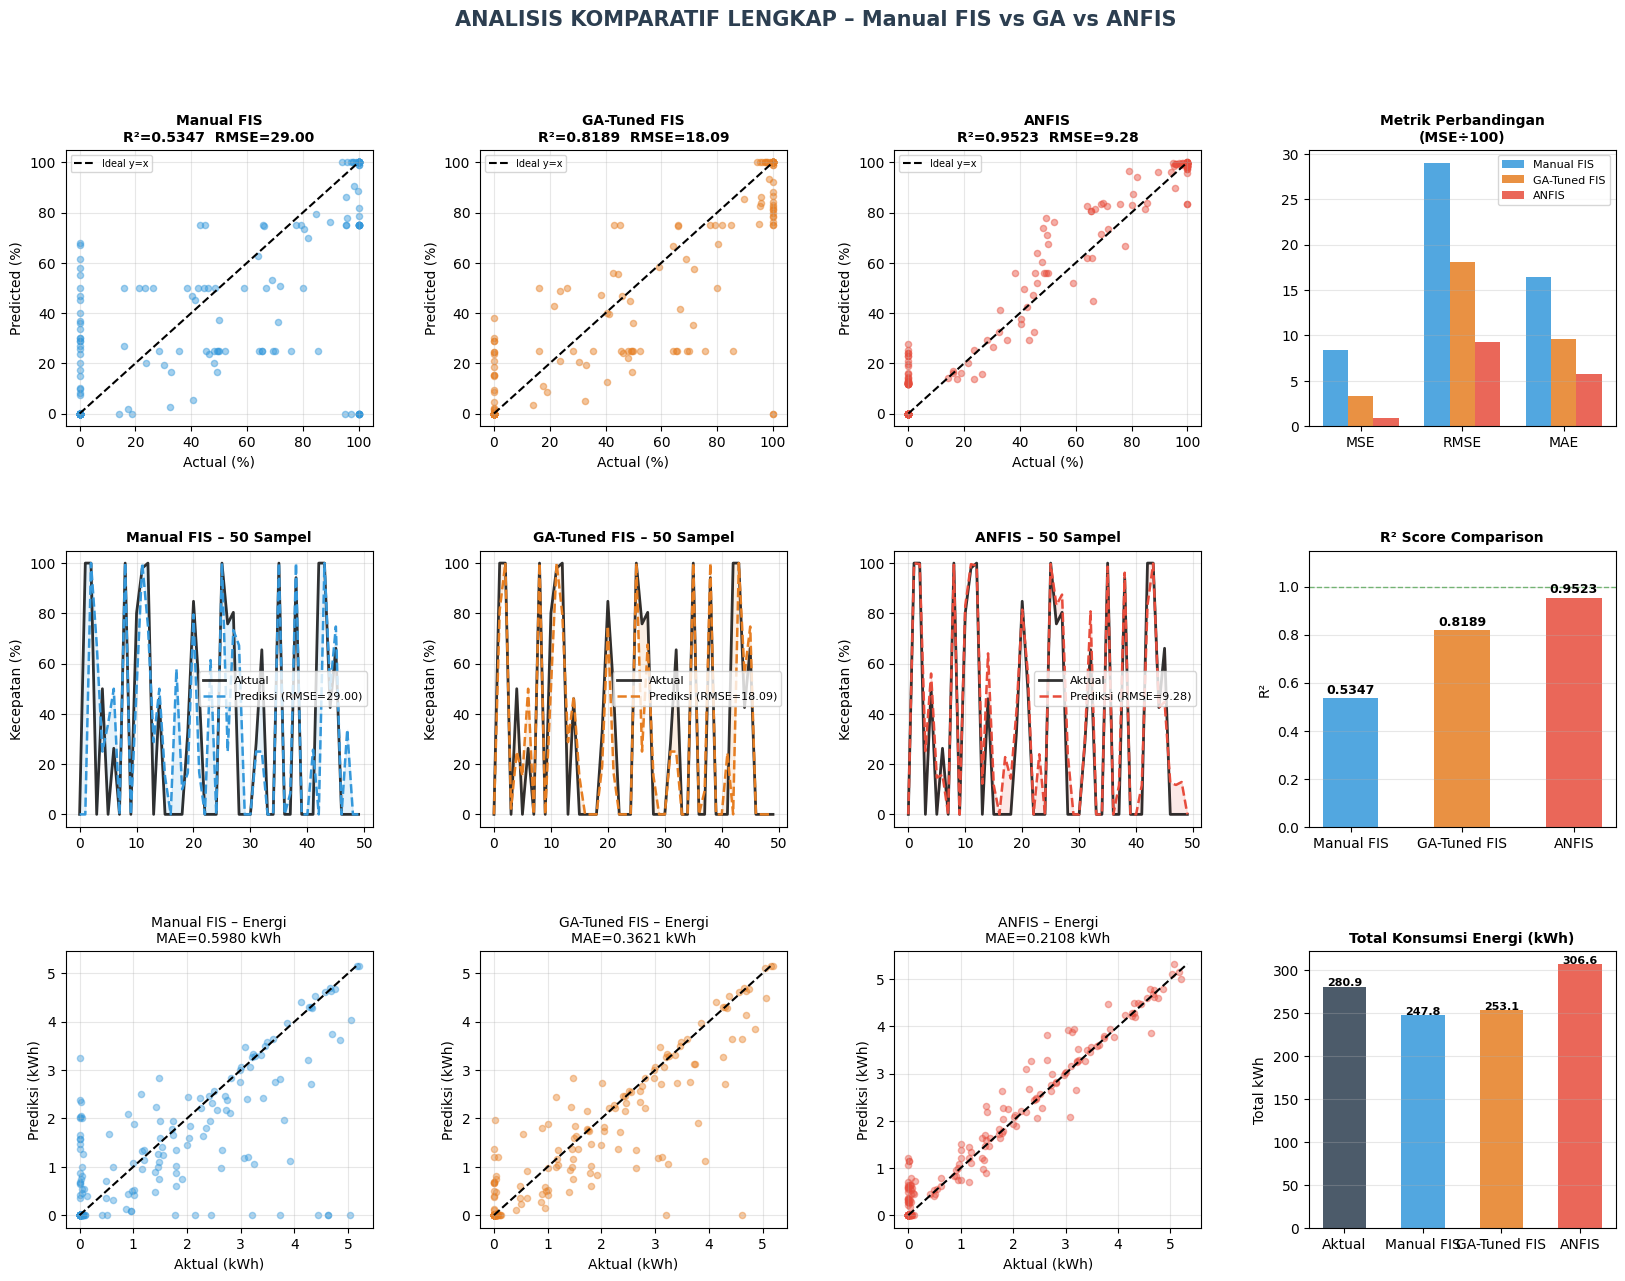

✅ Full comparison plot → artifacts/full_comparison.png


In [25]:
fig = plt.figure(figsize=(20, 14))
gs  = GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('ANALISIS KOMPARATIF LENGKAP – Manual FIS vs GA vs ANFIS',
             fontsize=15, fontweight='bold', color='#2c3e50')

colors_model = ['#3498db', '#e67e22', '#e74c3c']
labels_model = ['Manual FIS', 'GA-Tuned FIS', 'ANFIS']
preds_cols   = ['Pred_Manual_FIS', 'Pred_GA_FIS', 'Pred_ANN_FIS']
energy_cols  = ['Energy_Manual_FIS', 'Energy_GA_FIS', 'Energy_ANN_FIS']
all_m        = [metrics_manual, metrics_ga, metrics_ann]
y_actual     = df['Kecepatan_Kompresor']

# ── Row 1: Scatter plots (3 model) + Bar RMSE ─────────────────────────────
for i in range(3):
    ax = fig.add_subplot(gs[0, i])
    ax.scatter(y_actual, df[preds_cols[i]], alpha=0.45, color=colors_model[i], s=20)
    ax.plot([0,100],[0,100],'k--', linewidth=1.5, label='Ideal y=x')
    ax.set_title(f'{labels_model[i]}\nR²={all_m[i]["R2"]:.4f}  RMSE={all_m[i]["RMSE"]:.2f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual (%)'); ax.set_ylabel('Predicted (%)')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    ax.set_xlim(-5,105); ax.set_ylim(-5,105)

ax_bar = fig.add_subplot(gs[0, 3])
metric_names = ['MSE', 'RMSE', 'MAE']
x_pos = np.arange(len(metric_names))
width = 0.25
for i, (m, c) in enumerate(zip(all_m, colors_model)):
    vals = [m['MSE']/100, m['RMSE'], m['MAE']]  # MSE dibagi 100 agar skala comparable
    ax_bar.bar(x_pos + i*width, vals, width, label=labels_model[i], color=c, alpha=0.85)
ax_bar.set_title('Metrik Perbandingan\n(MSE÷100)', fontsize=10, fontweight='bold')
ax_bar.set_xticks(x_pos + width); ax_bar.set_xticklabels(metric_names)
ax_bar.legend(fontsize=8); ax_bar.grid(True, alpha=0.3, axis='y')

# ── Row 2: Line plot prediksi 50 sampel ────────────────────────────────────
n_show = 50
for i in range(3):
    ax = fig.add_subplot(gs[1, i])
    ax.plot(range(n_show), y_actual.values[:n_show], 'k-', linewidth=2, alpha=0.8, label='Aktual')
    ax.plot(range(n_show), df[preds_cols[i]].values[:n_show],
            color=colors_model[i], linewidth=1.8, linestyle='--',
            label=f'Prediksi (RMSE={all_m[i]["RMSE"]:.2f})')
    ax.fill_between(range(n_show), y_actual.values[:n_show],
                    df[preds_cols[i]].values[:n_show], alpha=0.12, color=colors_model[i])
    ax.set_title(f'{labels_model[i]} – 50 Sampel', fontsize=10, fontweight='bold')
    ax.set_ylabel('Kecepatan (%)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# R² bar chart
ax_r2 = fig.add_subplot(gs[1, 3])
r2_vals = [m['R2'] for m in all_m]
bars_r2 = ax_r2.bar(labels_model, r2_vals, color=colors_model, alpha=0.85, width=0.5)
ax_r2.axhline(1.0, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax_r2.set_title('R² Score Comparison', fontsize=10, fontweight='bold')
ax_r2.set_ylabel('R²'); ax_r2.set_ylim(0, 1.15)
ax_r2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars_r2, r2_vals):
    ax_r2.text(bar.get_x()+bar.get_width()/2, val+0.02, f'{val:.4f}',
               ha='center', fontsize=9, fontweight='bold')

# ── Row 3: Energi komparatif ───────────────────────────────────────────────
# Energi scatter: Aktual vs Prediksi
for i in range(3):
    ax = fig.add_subplot(gs[2, i])
    ax.scatter(df['Konsumsi_Energi'], df[energy_cols[i]],
               alpha=0.4, color=colors_model[i], s=20)
    max_e = max(df['Konsumsi_Energi'].max(), df[energy_cols[i]].max())
    ax.plot([0, max_e],[0, max_e],'k--', linewidth=1.5)
    mae_e = float(np.mean(np.abs(df[energy_cols[i]] - df['Konsumsi_Energi'])))
    ax.set_title(f'{labels_model[i]} – Energi\nMAE={mae_e:.4f} kWh', fontsize=10)
    ax.set_xlabel('Aktual (kWh)'); ax.set_ylabel('Prediksi (kWh)')
    ax.grid(True, alpha=0.3)

# Energi bar: Total konsumsi
ax_e = fig.add_subplot(gs[2, 3])
all_labels_e = ['Aktual'] + labels_model
all_totals   = [
    df['Konsumsi_Energi'].sum(),
    df['Energy_Manual_FIS'].sum(),
    df['Energy_GA_FIS'].sum(),
    df['Energy_ANN_FIS'].sum()
]
bar_colors_e = ['#2c3e50'] + colors_model
bars_e = ax_e.bar(all_labels_e, all_totals, color=bar_colors_e, alpha=0.85, width=0.55)
ax_e.set_title('Total Konsumsi Energi (kWh)', fontsize=10, fontweight='bold')
ax_e.set_ylabel('Total kWh'); ax_e.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars_e, all_totals):
    ax_e.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.1f}',
              ha='center', fontsize=8, fontweight='bold')

plt.savefig('artifacts/full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Full comparison plot → artifacts/full_comparison.png")

### 6.4 – Visualisasi Pergeseran MF: Manual vs GA vs ANFIS (Final)

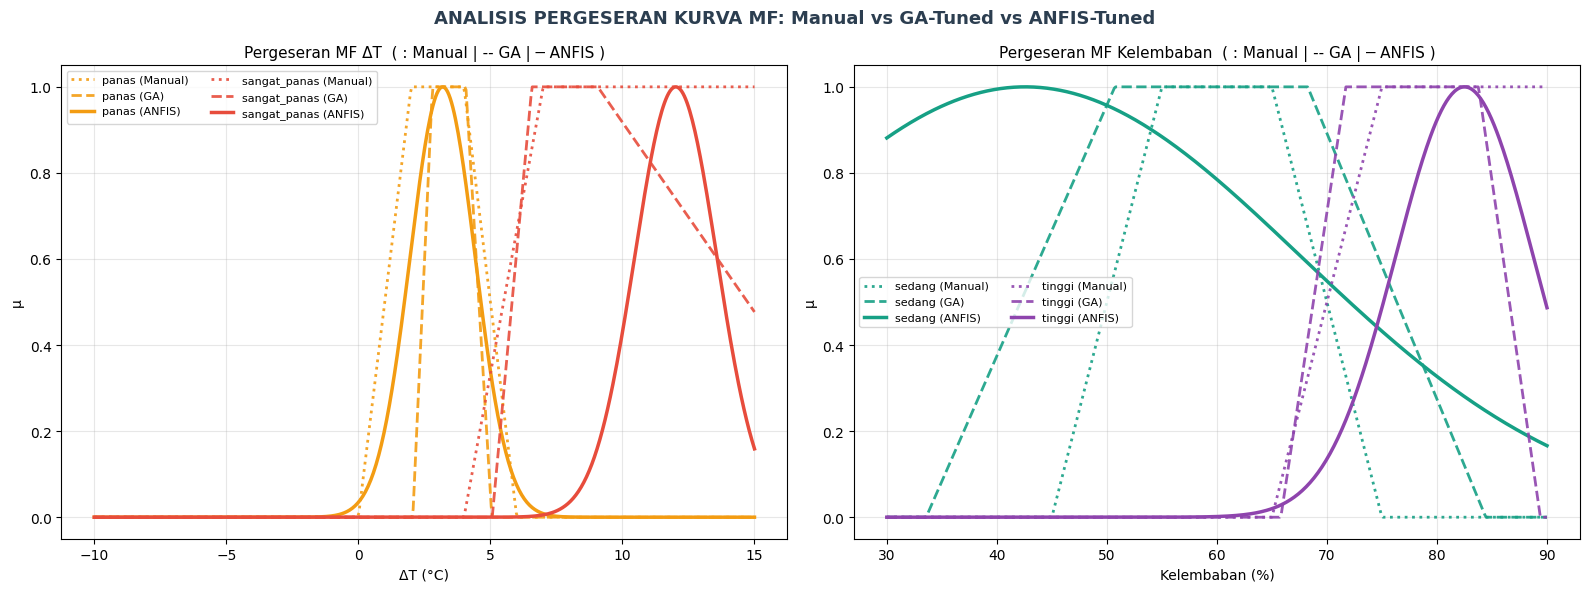

✅ MF shift final → artifacts/mf_shift_final.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ANALISIS PERGESERAN KURVA MF: Manual vs GA-Tuned vs ANFIS-Tuned',
             fontsize=13, fontweight='bold', color='#2c3e50')

x_dT = np.linspace(-10, 15, 500)
x_kl = np.linspace(30, 90, 500)
ax1, ax2 = axes

for lbl, color in [('panas','#f39c12'), ('sangat_panas','#e74c3c')]:
    y_m = trapezoid_mf(x_dT, *MANUAL_MF_PARAMS['delta_T'][lbl])
    y_g = trapezoid_mf(x_dT, *ga_mf_params['delta_T'][lbl])
    y_a = np.array([anfis.deltaT_mf[lbl].eval(x) for x in x_dT])
    ax1.plot(x_dT, y_m, color=color, lw=2,   ls=':',  alpha=0.9, label=f'{lbl} (Manual)')
    ax1.plot(x_dT, y_g, color=color, lw=2,   ls='--', alpha=0.9, label=f'{lbl} (GA)')
    ax1.plot(x_dT, y_a, color=color, lw=2.5, ls='-',             label=f'{lbl} (ANFIS)')

ax1.set_title('Pergeseran MF ΔT  ( : Manual | -- GA | ─ ANFIS )', fontsize=11)
ax1.set_xlabel('ΔT (°C)'); ax1.set_ylabel('μ')
ax1.legend(fontsize=8, ncol=2); ax1.grid(True, alpha=0.3)

for lbl, color in [('sedang','#16a085'), ('tinggi','#8e44ad')]:
    y_m = trapezoid_mf(x_kl, *MANUAL_MF_PARAMS['kelembaban'][lbl])
    y_g = trapezoid_mf(x_kl, *ga_mf_params['kelembaban'][lbl])
    y_a = np.array([anfis.kl_mf[lbl].eval(x) for x in x_kl])
    ax2.plot(x_kl, y_m, color=color, lw=2,   ls=':',  alpha=0.9, label=f'{lbl} (Manual)')
    ax2.plot(x_kl, y_g, color=color, lw=2,   ls='--', alpha=0.9, label=f'{lbl} (GA)')
    ax2.plot(x_kl, y_a, color=color, lw=2.5, ls='-',             label=f'{lbl} (ANFIS)')

ax2.set_title('Pergeseran MF Kelembaban  ( : Manual | -- GA | ─ ANFIS )', fontsize=11)
ax2.set_xlabel('Kelembaban (%)'); ax2.set_ylabel('μ')
ax2.legend(fontsize=8, ncol=2); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/mf_shift_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ MF shift final → artifacts/mf_shift_final.png")

---
## SECTION 7: EXPORT SEMUA FILE KE GOOGLE DRIVE

In [27]:
import os, shutil

# Cek semua artifacts
print("DAFTAR SEMUA FILE ARTIFACTS:")
print("─" * 60)
total_files = 0

def list_dir_recursive(path, indent=0):
    global total_files
    for entry in sorted(os.listdir(path)):
        full = os.path.join(path, entry)
        if os.path.isfile(full):
            size_kb = os.path.getsize(full) / 1024
            print(f"  {'  '*indent}📄 {entry:<45} ({size_kb:6.1f} KB)")
            total_files += 1
        elif os.path.isdir(full):
            print(f"  {'  '*indent}📂 {entry}/")
            list_dir_recursive(full, indent+1)

if os.path.exists('artifacts'):
    list_dir_recursive('artifacts')

print()
print(f"Total: {total_files} file")
print()

# Upload ke Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')

    target_path = '/content/drive/My Drive/UTS_SC_OUTPUT'
    if os.path.exists(target_path):
        shutil.rmtree(target_path)
    shutil.copytree('artifacts', target_path)

    print(f"✅ Semua file tersalin ke Google Drive: {target_path}")
except Exception as e:
    print(f"ℹ️  Google Drive tidak tersedia atau error: {e}")
    print("   Download folder 'artifacts' secara manual.")

print()
print("🎉 NOTEBOOK SELESAI DIJALANKAN!")
print("=" * 60)
print("  Output Final:")
print("  ✅ Dataset (200 baris) dengan kolom Konsumsi_Energi")
print("  ✅ Manual FIS + GA + ANFIS – evaluasi metrik lengkap")
print("  ✅ Konsumsi energi terhitung untuk ketiga model")
print("  ✅ Ablation Study 8 konfigurasi + deteksi konvergensi prematur")
print("  ✅ Semua visualisasi tersimpan sebagai PNG")
print("  ✅ Streamlit app.py dengan 7 tab fitur lengkap")
print("  ✅ README.md panduan penggunaan")
print("=" * 60)

DAFTAR SEMUA FILE ARTIFACTS:
────────────────────────────────────────────────────────────
  📂 ablation/
    📄 ablation_full_analysis.png                    ( 258.4 KB)
    📄 ablation_results.json                         (   1.8 KB)
  📄 anfis_history.json                            (   6.3 KB)
  📄 anfis_loss_mf.png                             ( 275.9 KB)
  📄 anfis_mf.json                                 (   1.3 KB)
  📂 ann_model/
  📄 dataset_eda.png                               ( 214.9 KB)
  📄 dataset_smart_ac.csv                          (   9.4 KB)
  📄 energy_metrics.json                           (   0.4 KB)
  📄 full_comparison.png                           ( 641.2 KB)
  📄 ga_convergence_mf_shift.png                   ( 217.4 KB)
  📄 ga_history.json                               (   8.4 KB)
  📄 ga_mf.json                                    (   0.9 KB)
  📄 metrics.json                                  (   0.4 KB)
  📄 mf_manual_before.png                          ( 147.5 KB)
  📄 mf_sh